# 🧠 Vector Space Proximity Workshop

## 🎯 What You'll Learn

By the end of this workshop, you will be able to:
1. Explain why documents and queries are represented as **vectors** in high-dimensional space
2. Compute **cosine similarity** and explain why it works better than Euclidean distance
3. Build an **unranked retrieval** system and evaluate it with Precision, Recall, and F1-score
4. Compute and interpret a **confusion matrix** for an IR system
5. Rank documents and evaluate a **ranked retrieval** system using **P@K**, **AP**, and **MRR**
6. Draw and interpret a **precision-recall curve** and an **interpolated precision curve**
7. Measure how much two human judges agree using **Cohen's Kappa**
8. Connect **classical IR** (TF-IDF, cosine similarity) to **modern AI systems** (embeddings, RAG)

---

## 📖 Key Vocabulary

| Term | Simple Explanation |
|------|-------------------|
| **Vector** | A list of numbers representing a document — each number is a word's weight |
| **High-dimensional Space** | A mathematical space with one axis per unique word in the vocabulary |
| **Cosine Similarity** | How similar two vectors are by measuring the *angle* between them, not the distance |
| **TF-IDF** | A weight that rewards words frequent in one document but rare across the corpus |
| **Precision** | Out of all the documents we retrieved, what fraction were actually relevant? |
| **Recall** | Out of all the relevant documents that exist, what fraction did we retrieve? |
| **F1-Score** | A balanced score combining Precision and Recall equally |
| **Ranked Retrieval** | Sorting search results so the most relevant documents appear first |
| **Precision@K** | Precision measured over only the top K retrieved documents |
| **Average Precision (AP)** | A summary score that rewards putting relevant docs near the top of a ranked list |
| **MRR** | Mean Reciprocal Rank — how quickly we hit the first relevant result |
| **Interpolated Precision** | A smoothed precision curve for fair comparison between IR systems |
| **Cohen's Kappa (κ)** | Measures how well two human judges agree — corrected for chance |


### 🔹 Introduction to Vector Space Proximity

A large majority of the data on the Internet is **unstructured**, for example: social media posts, emails, images, videos and audio files.

If we want to **persist** all these media in a database, we may add **metadata** about them, such as file type or creation date timestamp, or we could  **tag** each file, or parts of it, so they are easy to search for. This is because it would be very difficult to identify them based on their low-level (byte) representations.

But, what if we want to make the process fully automated (i.e., remove the need to manually add features, like tags, to each media item)? We need another way to represent the semantics of digital media.

That is the reason why in **Information Retrieval (IR)** and **Natural Language Processing (NLP)**, we often represent documents and queries as **vectors** in a **high-dimensional space**, where:

* Each **dimension** corresponds to a **unique term** in the vocabulary.
* A **document** is represented by a **point** or a **vector** in the space.
* A **vector** is a list of weights (e.g., term frequencies, TF-IDF values) that describe the presence or importance of terms in a document or query.

---

#### 📘 Example 1: "Rich" and "Poor" Axes

![Vector Space Example: "Rich" and "Poor" Axes"](./images/Fig1_CartesianVectorSpace.png)

Suppose our vocabulary only has two terms:

* `"rich"`
* `"poor"`

These two terms define a **2D Cartesian space**:

* The **x-axis** corresponds to the term **"rich"**.
* The **y-axis** corresponds to the term **"poor"**.

Each document is represented as a vector in this space:

* A document with many occurrences of “poor” and none of “rich” lies near the **y-axis**.
* A document that mentions both “rich” and “poor” lies in the **first quadrant**.
* A document with only “rich” is aligned along the **x-axis**.

The **query vector** $q = \{\text{"rich"}, \text{"poor"}\}$ points in the direction of interest for the search engine.

### 🔹 Euclidean Distance and Its Limitations

One might assume we can measure similarity using **Euclidean distance**:

$$
\text{Euclidean}( \vec{q}, \vec{d} ) = \sqrt{ \sum_{i=1}^{n} (q_i - d_i)^2 }
$$

However, this has problems in practice:

* If document $d_2$ contains more occurrences of both “rich” and “poor” than the query, its vector will have a **longer length**.
* As seen in the diagram, even though $d_2$ has strong content overlap with the query $q$, it may still be **further away** in Euclidean terms than unrelated documents like $d_3$.
* This happens because **magnitude dominates**, not direction.

### 🔹 Angle as Similarity → Cosine Similarity

To solve this, we focus on **vector direction**, not length. We measure **angle** between the document and query vectors using **Cosine Similarity**:

$$
\cos(\vec{q}, \vec{d}) = \frac{ \vec{q} \cdot \vec{d} }{ \|\vec{q}\| \cdot \|\vec{d}\| }
= \frac{ \sum_{i=1}^{n} q_i \cdot d_i }{ \sqrt{ \sum_{i=1}^{n} q_i^2 } \cdot \sqrt{ \sum_{i=1}^{n} d_i^2 } }
$$

* This gives us a similarity score from **0 (orthogonal)** to **1 (identical direction)**.
* Longer documents that are semantically aligned still get **high similarity**.

### 🔹 Why Cosine Similarity Works Better

* **Angle** captures **semantic alignment**.
* It is **not affected** by document length or repetition.
* Example: duplicating document $d$ to make $d'$ will increase Euclidean distance — but **cosine similarity remains 1**.

Cosine similarity is at the core of:

* **Search ranking**
* **Embedding-based retrieval**
* **LLM scoring and attention mechanisms**

Sample code:

In [1]:
# ─── Workshop Setup ──────────────────────────────────────────────────────────
# Run this cell first — it loads common libraries and sets a clean visual style.

import warnings
warnings.filterwarnings('ignore')   # Suppress warnings to keep output clean

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')          # Clean white-background grid for all plots
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 12

print("\u2705 Setup complete — libraries loaded and plot style configured!")

✅ Setup complete — libraries loaded and plot style configured!


In [2]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Define the documents and the query
documents = [
    "Ranks of starving poets swell",       # d1
    "Rich poor gap grows",                 # d2
    "Record baseball salaries in 2010"     # d3
]

query = ["rich poor"]                     # q

# Create a CountVectorizer to convert text to term frequency vectors
vectorizer = CountVectorizer()
doc_vectors = vectorizer.fit_transform(documents + query).toarray()

# Separate vectors
doc_matrix = doc_vectors[:3]  # d1, d2, d3
query_vector = doc_vectors[3].reshape(1, -1)  # q

# Compute cosine similarity
cosine_similarities = cosine_similarity(query_vector, doc_matrix).flatten()

# Create a DataFrame to show results
df = pd.DataFrame({
    'Document': ['Doc1', 'Doc2', 'Doc3'],
    'Cosine Similarity with Query': cosine_similarities
})

# Sort for clarity
print("Query: ", query)
df.sort_values(by='Cosine Similarity with Query', ascending=False, inplace=True)
df.reset_index(drop=True, inplace=True)

# Display the result
df


Query:  ['rich poor']


,Document,Cosine Similarity with Query
0,Doc2,0.707107
1,Doc1,0.000000
2,Doc3,0.000000


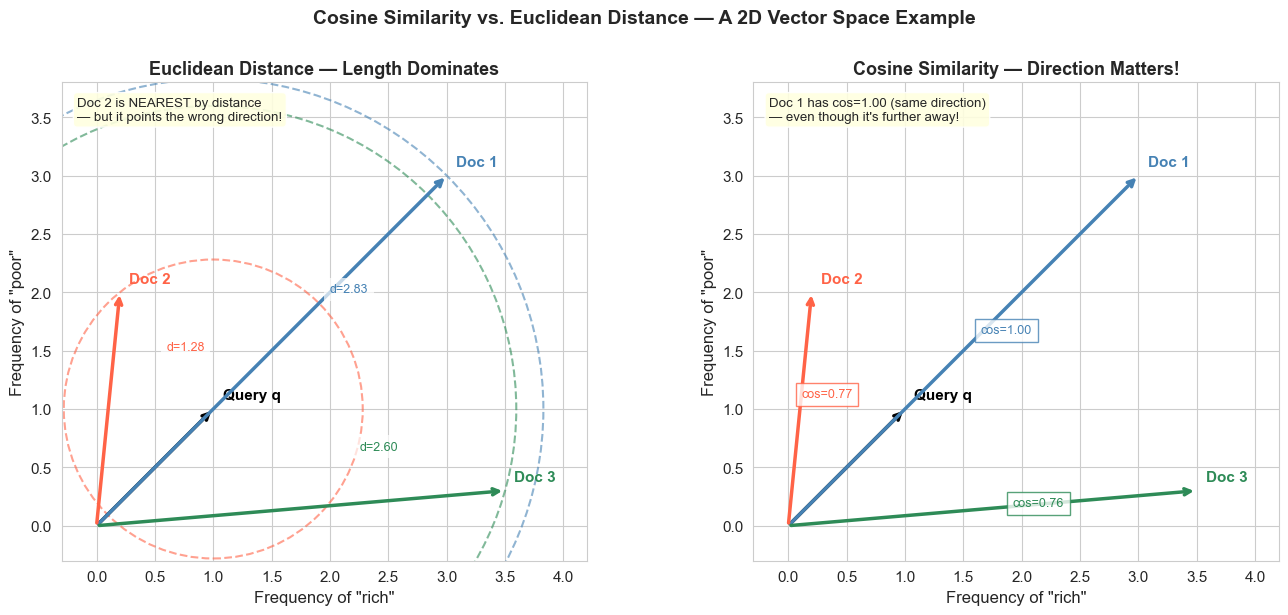


📊 Comparing Euclidean Distance vs. Cosine Similarity (query = (1, 1)):
Document             Euclidean Dist   Cosine Sim
------------------------------------------------
Doc 1  (3.0, 3.0)             2.828        1.000
Doc 2  (0.2, 2.0)             1.281        0.774
Doc 3  (3.5, 0.3)             2.596        0.765

Doc 1 scores highest by cosine (1.000) but WORST by Euclidean distance!
This is why search engines use cosine similarity — document length is irrelevant.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ─── Visualising Cosine Similarity vs. Euclidean Distance ────────────────────
#
# Imagine our vocabulary has only two words: "rich" and "poor".
# Every document becomes a POINT on a 2D graph:
#   x-axis = how many times "rich" appears
#   y-axis = how many times "poor" appears
#
# The QUERY is also a point in this same 2D space.
#
# EUCLIDEAN DISTANCE asks: "How far apart are these two points?"
# COSINE SIMILARITY asks: "Are they pointing in the same DIRECTION?"
#
# For information retrieval, DIRECTION matters more than DISTANCE!

sns.set_style('whitegrid')

# Define example 2D vectors: (frequency of "rich", frequency of "poor")
# random_state=42 not needed here — we define vectors explicitly
q  = np.array([1.0, 1.0])    # Query: mentions "rich" and "poor" equally
d1 = np.array([3.0, 3.0])    # Doc1: same direction as query, just longer (more words)
d2 = np.array([0.2, 2.0])    # Doc2: closer in distance but mostly about "poor"
d3 = np.array([3.5, 0.3])    # Doc3: mostly about "rich" — wrong direction for this query

colors = {'Query q': 'black', 'Doc 1': 'steelblue', 'Doc 2': 'tomato', 'Doc 3': 'seagreen'}
vecs   = {'Query q': q,       'Doc 1': d1,           'Doc 2': d2,       'Doc 3': d3}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, show_euclidean in zip(axes, [True, False]):
    # Draw each vector as an arrow from the origin
    for label, vec in vecs.items():
        ax.annotate("", xy=vec, xytext=(0.0, 0.0),
                    arrowprops=dict(arrowstyle="->", color=colors[label], lw=2.5))
        ax.text(vec[0] + 0.08, vec[1] + 0.08, label,
                color=colors[label], fontsize=11, fontweight='bold')

    if show_euclidean:
        ax.set_title("Euclidean Distance — Length Dominates", fontsize=13, fontweight='bold')
        for label, vec in [('Doc 1', d1), ('Doc 2', d2), ('Doc 3', d3)]:
            dist = np.linalg.norm(vec - q)
            circle = plt.Circle(q, dist, fill=False, linestyle='--',
                                color=colors[label], alpha=0.6, lw=1.5)
            ax.add_patch(circle)
            midpoint = q + (vec - q) * 0.5
            ax.text(midpoint[0], midpoint[1], f'd={dist:.2f}', fontsize=9,
                    color=colors[label],
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
        note = "Doc 2 is NEAREST by distance\n— but it points the wrong direction!"
    else:
        ax.set_title("Cosine Similarity — Direction Matters!", fontsize=13, fontweight='bold')
        for label, vec in [('Doc 1', d1), ('Doc 2', d2), ('Doc 3', d3)]:
            cos_sim = np.dot(q, vec) / (np.linalg.norm(q) * np.linalg.norm(vec))
            midpoint = vec * 0.55
            ax.text(midpoint[0], midpoint[1], f'cos={cos_sim:.2f}', fontsize=9,
                    color=colors[label],
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor=colors[label]))
        note = "Doc 1 has cos=1.00 (same direction)\n— even though it's further away!"

    ax.text(0.03, 0.97, note, transform=ax.transAxes, fontsize=9.5,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))
    ax.set_xlabel('Frequency of "rich"', fontsize=12)
    ax.set_ylabel('Frequency of "poor"', fontsize=12)
    ax.set_xlim(-0.3, 4.2)
    ax.set_ylim(-0.3, 3.8)
    ax.set_aspect('equal', adjustable='box')

plt.suptitle('Cosine Similarity vs. Euclidean Distance — A 2D Vector Space Example',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Summary comparison table
print("\n📊 Comparing Euclidean Distance vs. Cosine Similarity (query = (1, 1)):")
print(f"{'Document':<18} {'Euclidean Dist':>16} {'Cosine Sim':>12}")
print("-" * 48)
for label, vec in [('Doc 1  (3.0, 3.0)', d1), ('Doc 2  (0.2, 2.0)', d2), ('Doc 3  (3.5, 0.3)', d3)]:
    euc = np.linalg.norm(vec - q)
    cos = np.dot(q, vec) / (np.linalg.norm(q) * np.linalg.norm(vec))
    print(f"{label:<18} {euc:>16.3f} {cos:>12.3f}")

print("\nDoc 1 scores highest by cosine (1.000) but WORST by Euclidean distance!")
print("This is why search engines use cosine similarity — document length is irrelevant.")

**What Do We See Here?**

- **Left panel — Euclidean Distance**: The dashed circles show how far each document is from the query. *Doc 2* is the closest in distance — but it points mostly toward "poor", not "rich + poor" equally like the query.
- **Right panel — Cosine Similarity**: *Doc 1* scores a perfect 1.00. It has the exact same *direction* as the query, even though it's much further away in raw distance.
- **The key lesson**: In information retrieval, we care about *topical alignment* (direction), not document length (magnitude). Cosine similarity captures this perfectly.

🗣️ **Instructor Talking Point**: Use the compass analogy — a compass tells you *direction*, not how far. A document that consistently points toward the same themes as the query is a good match regardless of how long it is. This is why cosine similarity is the default choice for text retrieval.

🧠 **Student Talking Point**: Can you think of a real search scenario where a longer, more detailed document should rank higher than a very short one that accidentally uses the right words? How does cosine similarity handle this correctly?

### 📘 Example 2: Word Vectors in a Small Corpus

Let's start with a small corpus of just six words, each represented by a vector in 3D space:

```plaintext
CAT     → [ 0.2, -0.4,  0.7]
DOG     → [ 0.6,  0.1,  0.5]
APPLE   → [ 0.8, -0.2, -0.3]
ORANGE  → [ 0.7, -0.1, -0.6]
HAPPY   → [-0.5,  0.9,  0.2]
SAD     → [ 0.4, -0.7, -0.5]
```

Each term is represented by a **vector in 3D space**.

### 🔍 Observations

- Words with **similar meanings** tend to have **similar vector representations**.
  - For example, **APPLE** and **ORANGE** are close in vector space, reflecting their semantic similarity.

- Words with **opposite meanings** tend to have **vectors pointing in opposite directions**.
  - For instance, **HAPPY** and **SAD** have contrasting vectors, indicating their opposing emotional tones.

![3D Visualization of Word Vectors](./images/Fig2_3DVisualizationWordVectors.png)


### 🔹 Embeddings and Frequency-Based Representations

Vector representations are also called **embeddings**.

One simple family of embeddings is **frequency-based embeddings**. These represent documents numerically using statistics derived from the corpus. A classical example is **TF-IDF**.

TF-IDF highlights words that are frequent within a specific document but rare across the entire corpus. For example, in a document about music, it would emphasize words such as **rap**, **disco**, **pop**, and **rock**, while common pronouns and function words receive low weights.

This workshop stays focused on **Vector Space Proximity** and the use of these vector representations for **matching**, **retrieval**, and **evaluation**.


### 🔹 Transition to Evaluation

Once we represent documents and queries as vectors and compute proximity scores, the next question is:

> **How do we know whether the retrieval system is doing a good job?**

To answer that, we need **evaluation**.


## 🔹 Evaluation of an Information Retrieval System

In Information Retrieval, an **information need** is translated into a **query**.

For example:

- **Information need**: *I want information on whether drinking green tea is more effective than coffee at reducing the risk of heart attacks.*
- **Possible query**: `green tea coffee heart attack effective`

This distinction matters because **relevance is assessed relative to the information need, not the query string itself**.

A document is **relevant** if it addresses the user's real need. A document is **not automatically relevant** just because it contains the words `green`, `tea`, `coffee`, or `heart attack`.

### ✅ Key idea

When evaluating an IR system, we ask:

- Did the system retrieve documents that actually satisfy the information need?
- Not merely: did the system retrieve documents that share words with the query?


In [4]:
import pandas as pd

# Benchmark collection for one information need
documents_eval = {
    "Doc1": "A medical review compares green tea and coffee for cardiovascular health and heart attack risk.",
    "Doc2": "Green tea contains antioxidants that may support heart health.",
    "Doc3": "Coffee prices increased this year because of climate conditions affecting crops.",
    "Doc4": "Heart attack warning signs and emergency response guidelines.",
    "Doc5": "A study discusses whether green tea is more effective than coffee in lowering heart attack risk.",
    "Doc6": "The history of tea drinking in East Asia."
}

information_need = (
    "Find information on whether drinking green tea is more effective than coffee "
    "at reducing the risk of heart attacks."
)

query_eval = "green tea coffee heart attack effective"

benchmark_df = pd.DataFrame({
    "Document": list(documents_eval.keys()),
    "Text": list(documents_eval.values())
})

print("Information Need:")
print(information_need)
print("\nQuery:")
print(query_eval)
print("\nBenchmark Collection:")
benchmark_df


Information Need:
Find information on whether drinking green tea is more effective than coffee at reducing the risk of heart attacks.

Query:
green tea coffee heart attack effective

Benchmark Collection:


,Document,Text
0,Doc1,A medical review compares green tea and coffee...
1,Doc2,Green tea contains antioxidants that may suppo...
2,Doc3,Coffee prices increased this year because of c...
3,Doc4,Heart attack warning signs and emergency respo...
4,Doc5,A study discusses whether green tea is more ef...
5,Doc6,The history of tea drinking in East Asia.


**What Do We See Here?**

- We have **6 documents** on various topics — only some directly address our information need.
- **Doc 5** directly compares green tea vs. coffee for heart attack risk — clearly relevant.
- **Doc 1** is also relevant (a medical review of the same comparison).
- Docs 2, 3, 4, and 6 contain some query words but don't actually answer the comparison question.

🗣️ **Instructor Talking Point**: Relevance is *not* determined by keyword overlap. Doc 3 mentions coffee — but it's about crop prices, not health. Relevance is always relative to the *information need*, not the query string. This is the most important distinction in IR evaluation.

🧠 **Student Talking Point**: Look at Doc 4 (heart attack warning signs). It contains "heart attack" — but does it answer the question of *which drink is more effective*? Justify your relevance label.

## 🔹 Evaluating Unranked Results

For **unranked retrieval**, the system returns a **set** of documents, not an ordered list.

To evaluate such a result set, we usually need:

- A **benchmark document collection**
- A **benchmark set of queries**
- A **relevance assessment** for each query-document pair, often created manually by experts

This turns the problem into a **classification-style setup**:

- **Relevant**
- **Nonrelevant**

### Important note

Although **accuracy** is common in machine learning classification, it is **not the main metric in IR**.

Why?

Because in IR, the number of nonrelevant documents is often huge. A system can get high accuracy simply by labeling most documents as nonrelevant, while still failing to retrieve the relevant ones the user actually needs.

So for unranked IR, we focus on measures such as:

- **Precision**
- **Recall**
- **F1-score**

Where:

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

$$
F_1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
$$


In [5]:
from sklearn.feature_extraction.text import CountVectorizer

# Manual relevance judgments relative to the INFORMATION NEED, not just the query words.
# 1 = relevant, 0 = nonrelevant
relevance_judgments = {
    "Doc1": 1,  # directly compares green tea and coffee for heart attack risk
    "Doc2": 0,  # about green tea and heart health, but does not answer the comparison
    "Doc3": 0,  # contains coffee topic but unrelated to health effectiveness
    "Doc4": 0,  # about heart attacks, but not about green tea vs coffee
    "Doc5": 1,  # directly addresses the information need
    "Doc6": 0   # about tea history, not the medical comparison
}

# A simple UNRANKED retrieval rule:
# retrieve a document if it contains at least one query term
vectorizer_eval = CountVectorizer(binary=True)
X_eval = vectorizer_eval.fit_transform(list(documents_eval.values()) + [query_eval]).toarray()

doc_term_matrix = X_eval[:-1]
query_vector_eval = X_eval[-1]

# Unranked retrieval: retrieve if there is any overlap with the query
retrieved_flags = (doc_term_matrix @ query_vector_eval > 0).astype(int)

results_eval = pd.DataFrame({
    "Document": list(documents_eval.keys()),
    "Retrieved": retrieved_flags,
    "Relevant": [relevance_judgments[d] for d in documents_eval.keys()],
    "Text": list(documents_eval.values())
})

results_eval


,Document,Retrieved,Relevant,Text
0,Doc1,1,1,A medical review compares green tea and coffee...
1,Doc2,1,0,Green tea contains antioxidants that may suppo...
2,Doc3,1,0,Coffee prices increased this year because of c...
3,Doc4,1,0,Heart attack warning signs and emergency respo...
4,Doc5,1,1,A study discusses whether green tea is more ef...
5,Doc6,1,0,The history of tea drinking in East Asia.


**What Do We See Here?**

- The simple **term-overlap rule** retrieves any document containing at least one query term.
- Documents about coffee prices (Doc 3) and heart attack symptoms (Doc 4) are retrieved — even though they don't answer the question.
- Both truly relevant documents (Doc 1 and Doc 5) are retrieved, but so are several irrelevant ones.
- This is **high recall but low precision** retrieval — we find what we need, but with a lot of noise.

🗣️ **Instructor Talking Point**: Unranked retrieval returns a *set* with no ordering. This motivates **ranking** — ordering results so the most relevant appear first, where users actually look.

🧠 **Student Talking Point**: Before running the next cell, try computing Precision and Recall by hand from the Retrieved and Relevant columns. Which would you prioritise in a medical search engine? Why?

## 🔹 Computing Precision and Recall for the Unranked Result Set

Now we compare the system's retrieved set against the benchmark relevance judgments.

We define:

- **TP (True Positives)**: retrieved and relevant
- **FP (False Positives)**: retrieved but nonrelevant
- **FN (False Negatives)**: not retrieved but relevant
- **TN (True Negatives)**: not retrieved and nonrelevant

In IR, the most informative questions are:

- Of the documents we retrieved, how many were actually useful? → **Precision**
- Of all relevant documents that exist, how many did we find? → **Recall**

This tells us whether the retrieval strategy is too broad, too narrow, or balanced.


In [6]:
# Compute confusion-matrix style counts
tp = int(((results_eval["Retrieved"] == 1) & (results_eval["Relevant"] == 1)).sum())
fp = int(((results_eval["Retrieved"] == 1) & (results_eval["Relevant"] == 0)).sum())
fn = int(((results_eval["Retrieved"] == 0) & (results_eval["Relevant"] == 1)).sum())
tn = int(((results_eval["Retrieved"] == 0) & (results_eval["Relevant"] == 0)).sum())

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
accuracy = (tp + tn) / (tp + fp + fn + tn)

summary_df = pd.DataFrame({
    "Metric": ["TP", "FP", "FN", "TN", "Precision", "Recall", "F1", "Accuracy"],
    "Value": [tp, fp, fn, tn, round(precision, 3), round(recall, 3), round(f1, 3), round(accuracy, 3)]
})

summary_df


,Metric,Value
0,TP,2.000
1,FP,4.000
2,FN,0.000
3,TN,0.000
4,Precision,0.333
5,Recall,1.000
6,F1,0.500
7,Accuracy,0.333


**What Do We See Here?**

- **Precision**: only a fraction of retrieved documents are truly relevant.
- **Recall**: we found this fraction of all relevant documents that exist.
- **Accuracy** looks misleadingly high — because most documents are irrelevant (class imbalance), even a "retrieve nothing" system would score well on accuracy.
- **F1-score** is more honest: it requires both Precision AND Recall to be good simultaneously.

🗣️ **Instructor Talking Point**: In a 1,000-document collection with only 5 relevant documents, a system that retrieves *nothing* would have 99.5% accuracy. That's why IR uses Precision and Recall — not accuracy.

🧠 **Student Talking Point**: Imagine a spam filter that labels *every* email as spam to get perfect recall. What would its precision be? What about accuracy? Why are precision and recall together a better measure?

## 🔹 Interpreting the Results

Notice how **accuracy** can look acceptable even when the retrieval behavior is not ideal.

For IR, **precision** and **recall** are more meaningful because they focus on the documents that matter to the user's information need.

### Reflection questions for students

1. Which retrieved documents were **false positives**, and why?
2. Which relevant documents might be missed by a simple lexical query-matching rule?
3. How might **TF-IDF weighting** and **cosine similarity** improve retrieval compared with a simple overlap rule?
4. Why is relevance judged relative to the **information need** rather than the exact query wording?

This sets up the next step in IR evaluation: moving from **unranked result sets** to **ranked retrieval**, where order also matters.


## 🔹 Confusion Matrix for Unranked Retrieval

For **unranked IR evaluation**, we can summarize the result set using a **confusion matrix**.

We compare two things for each document:

- **Did the system retrieve it?**
- **Is it actually relevant to the information need?**

This gives four cases:

- **TP (True Positive)**: retrieved and relevant
- **FP (False Positive)**: retrieved but nonrelevant
- **FN (False Negative)**: not retrieved but relevant
- **TN (True Negative)**: not retrieved and nonrelevant

In IR notation:

- \( P \): total number of relevant documents
- \( N \): total number of nonrelevant documents
- \( \hat{P} \): number of retrieved documents
- \( \hat{N} \): number of not retrieved documents

The confusion matrix helps us connect retrieval behavior to evaluation metrics such as **precision**, **recall**, and **F-measure**.


In [7]:
import pandas as pd

# Build a simple confusion-matrix-style table from the counts already computed
confusion_display = pd.DataFrame(
    [
        [tp, fn, tp + fn],
        [fp, tn, fp + tn],
        [tp + fp, fn + tn, tp + fp + fn + tn]
    ],
    index=["Relevant", "Nonrelevant", "Total"],
    columns=["Retrieved", "Not retrieved", "Total"]
)

print("Confusion Matrix for the Unranked Result Set:")
confusion_display


Confusion Matrix for the Unranked Result Set:


,Retrieved,Not retrieved,Total
Relevant,2,0,2
Nonrelevant,4,0,4
Total,6,0,6


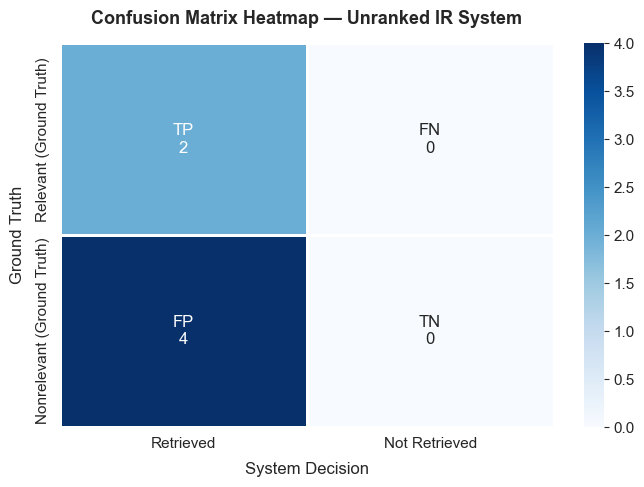

Precision = TP / (TP+FP) = 2 / 6 = 0.33
Recall    = TP / (TP+FN) = 2 / 2 = 1.00


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# ─── Confusion Matrix Heatmap ─────────────────────────────────────────────────
# A colour-coded heatmap makes the four quadrants instantly readable.
# Remember:
#   TP (top-left)  = we retrieved it AND it's relevant    → GOOD
#   FN (top-right) = we missed it even though it's relevant → BAD (missed opportunity)
#   FP (bot-left)  = we retrieved it but it's NOT relevant  → BAD (noise)
#   TN (bot-right) = we didn't retrieve it, and it wasn't relevant → OK

cm_2x2 = [[tp, fn], [fp, tn]]

# Custom annotations: acronym + count together
cm_annot = [[f'TP\n{tp}',  f'FN\n{fn}'],
            [f'FP\n{fp}',  f'TN\n{tn}']]

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm_2x2,
    annot=cm_annot,
    fmt='',              # We handle formatting in cm_annot ourselves
    cmap='Blues',
    linewidths=2,
    linecolor='white',
    xticklabels=['Retrieved', 'Not Retrieved'],
    yticklabels=['Relevant (Ground Truth)', 'Nonrelevant (Ground Truth)'],
    ax=ax,
    annot_kws={'fontsize': 12}
)
ax.set_title('Confusion Matrix Heatmap — Unranked IR System',
             fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('System Decision', fontsize=12, labelpad=8)
ax.set_ylabel('Ground Truth', fontsize=12, labelpad=8)
plt.tight_layout()
plt.show()

# Quick plain-English summary
prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
print(f"Precision = TP / (TP+FP) = {tp} / {tp+fp} = {prec:.2f}")
print(f"Recall    = TP / (TP+FN) = {tp} / {tp+fn} = {rec:.2f}")

**What Do We See Here?**

- Blue intensity shows the count in each quadrant — darker = more documents.
- Ideally, **TP** (top-left) should be dark and **FP + FN** (off-diagonal) should be light.
- **TP** = successful retrieval, **FP** = retrieved noise, **FN** = missed opportunity, **TN** = correct rejection.

🗣️ **Instructor Talking Point**: Confusion matrices appear in every classification problem in ML. Getting students comfortable with this layout now pays dividends in every future ML course.

🧠 **Student Talking Point**: If your IR system had very high FN (many missed relevant documents), what would you change to fix it? Would that change increase or decrease FP? Why does fixing one often make the other worse?

## 🔹 Precision–Recall Discussion

A key idea in Information Retrieval is the **tradeoff between precision and recall**.

### Precision

Precision asks:

> Of the documents the system retrieved, how many were actually relevant?

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

High precision means the system returns **few false positives**.

---

### Recall

Recall asks:

> Of all relevant documents in the collection, how many did the system find?

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

High recall means the system returns **few false negatives**.

---

### Why the tradeoff matters

- You can get **high recall** by retrieving many documents, even **all documents**
- But then precision usually drops, because many retrieved documents are nonrelevant
- In a good IR system, as the number of retrieved documents increases, **recall tends to go up** while **precision often goes down**

---

### F-Measure

To balance precision and recall, we often use the **F-measure** (harmonic mean):

$$
F_1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
$$

The harmonic mean is used because it penalizes systems that do well on one metric but poorly on the other.

### Key interpretation

- **High precision, low recall**: the system is conservative and misses relevant documents
- **Low precision, high recall**: the system retrieves many relevant documents, but also too many irrelevant ones
- **Balanced F1**: the system has a good compromise between the two


📋 Precision and Recall at each rank position k:


,k,Document,Relevant?,Precision@k,Recall@k
0,1,Doc5,1,1.000,0.5
1,2,Doc1,1,1.000,1.0
2,3,Doc2,0,0.667,1.0
3,4,Doc4,0,0.500,1.0
4,5,Doc3,0,0.400,1.0
5,6,Doc6,0,0.333,1.0


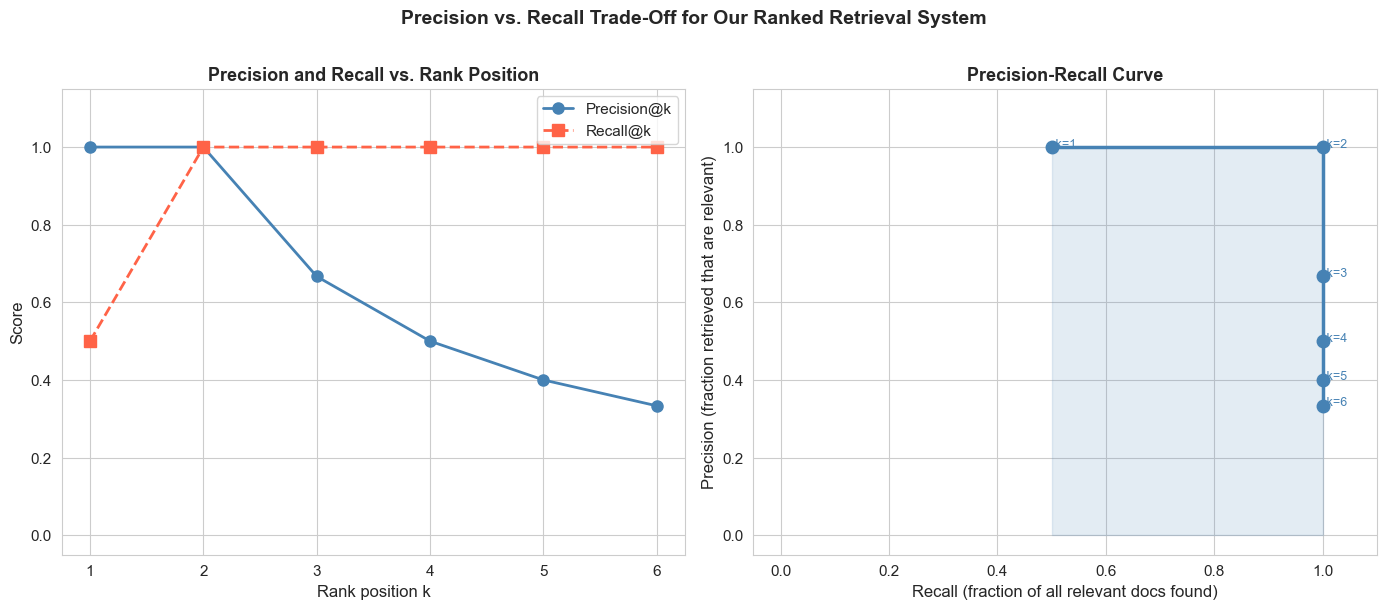

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ─── Building a Precision-Recall Curve ───────────────────────────────────────
# Think of this like a study experiment:
#   RECALL    = "How much of the relevant material did I cover?"
#   PRECISION = "Of everything I covered, how much was actually relevant?"
#
# Retrieving MORE documents usually improves recall but includes more junk —
# which hurts precision. That is the precision-recall TRADE-OFF.

sns.set_style('whitegrid')

# Rank documents by query overlap score (more overlap = higher rank)
overlap_scores = (doc_term_matrix @ query_vector_eval).astype(int)

ranked_df = pd.DataFrame({
    "Document": list(documents_eval.keys()),
    "OverlapScore": overlap_scores,
    "Relevant": [relevance_judgments[d] for d in documents_eval.keys()]
}).sort_values(by=["OverlapScore", "Document"], ascending=[False, True]).reset_index(drop=True)

precision_values = []
recall_values = []
k_values = []

num_relevant = ranked_df["Relevant"].sum()  # Total relevant docs in the whole collection
tp_running = 0

for k in range(1, len(ranked_df) + 1):
    if ranked_df.loc[k - 1, "Relevant"] == 1:
        tp_running += 1                     # Found another relevant document!

    precision_k = tp_running / k            # Precision@k = TP found / k docs retrieved
    recall_k = tp_running / num_relevant if num_relevant > 0 else 0  # Recall@k

    k_values.append(k)
    precision_values.append(precision_k)
    recall_values.append(recall_k)

pr_table = pd.DataFrame({
    "k": k_values,
    "Document": ranked_df["Document"],
    "Relevant?": ranked_df["Relevant"],
    "Precision@k": np.round(precision_values, 3),
    "Recall@k": np.round(recall_values, 3)
})

print("📋 Precision and Recall at each rank position k:")
display(pr_table)

# ─── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: P and R vs rank k
axes[0].plot(k_values, precision_values, marker="o", lw=2, color='steelblue',
             label='Precision@k', markersize=8)
axes[0].plot(k_values, recall_values, marker="s", lw=2, color='tomato',
             label='Recall@k', markersize=8, linestyle='--')
axes[0].set_xlabel("Rank position k", fontsize=12)
axes[0].set_ylabel("Score", fontsize=12)
axes[0].set_title("Precision and Recall vs. Rank Position", fontsize=13, fontweight='bold')
axes[0].set_ylim(-0.05, 1.15)
axes[0].legend(fontsize=11)

# Right: Precision-Recall curve
axes[1].plot(recall_values, precision_values, marker="o", lw=2.5,
             color='steelblue', markersize=9)
axes[1].fill_between(recall_values, precision_values, alpha=0.15, color='steelblue')
for rank, r, p in zip(k_values, recall_values, precision_values):
    axes[1].annotate(f" k={rank}", xy=(r, p), fontsize=9, color='steelblue')
axes[1].set_xlabel("Recall (fraction of all relevant docs found)", fontsize=12)
axes[1].set_ylabel("Precision (fraction retrieved that are relevant)", fontsize=12)
axes[1].set_title("Precision-Recall Curve", fontsize=13, fontweight='bold')
axes[1].set_xlim(-0.05, 1.1)
axes[1].set_ylim(-0.05, 1.15)

plt.suptitle("Precision vs. Recall Trade-Off for Our Ranked Retrieval System",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**What Do We See Here? — Precision-Recall Curve**

- **Left plot**: As rank K increases, Recall increases monotonically (every new result either finds a relevant doc or not), while Precision zigzags — rising when we find a relevant doc, falling when we don't.
- **Right plot (P-R curve)**: This is the classic precision-recall trade-off visualised. The curve moves right (more recall) as we retrieve more documents, but precision can drop.
- The **area under the P-R curve** is a measure of overall system quality — more area = better system.
- A perfect system would hug the top-right corner (high precision *and* high recall).

> 📌 **Key Bridge**: Simply returning *all* documents gives recall = 1.0 but terrible precision. Ranking lets us serve the highest-quality results first, making the first few results useful.

🗣️ **Instructor Talking Point**: Draw the "ideal" P-R curve on the board — a flat horizontal line at precision = 1.0 from recall 0 to 1.0. Every real system falls below this. The goal of better retrieval models is to push as close as possible to this ideal.

🧠 **Student Talking Point**: Look at the points on the P-R curve. Identify where precision dropped most. What document was at that rank? Was it a reasonable retrieval decision or a mistake by the system?

## 🔹 Interpolated Precision

A retrieval system can return **any number of results**, so the raw precision values observed along a ranking can fluctuate up and down.

To make the precision–recall curve easier to interpret, we use **interpolated precision**.

At a recall level \( r \), the interpolated precision is defined as:

$$
p_{\mathrm{interp}}(r) = \max_{r' \ge r} p(r')
$$

This means:

- look at the current recall level \( r \)
- look to the **right** on the precision–recall curve, at all recall levels \( r' \ge r \)
- take the **highest precision** found there

### Why do this?

It smooths the curve and answers the question:

> "At this recall level or beyond, what is the best precision the system achieves?"

This produces a non-increasing interpolated precision curve, which is often easier to compare across systems.


📋 Raw vs. Interpolated Precision at each recall level:


,Recall,Raw Precision,Interpolated Precision
0,0.5,1.000,1.000
1,1.0,1.000,1.000
2,1.0,0.667,0.667
3,1.0,0.500,0.500
4,1.0,0.400,0.400
5,1.0,0.333,0.333


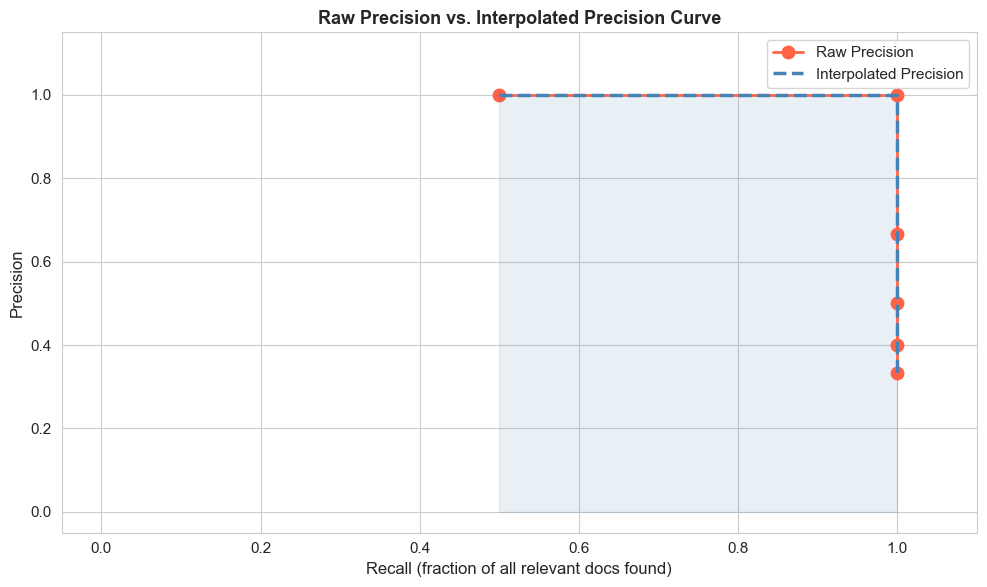


Interpolated precision can only stay flat or decrease as recall increases.
This is the core trade-off: more coverage always comes at a cost to precision.


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ─── Interpolated Precision ───────────────────────────────────────────────────
# The raw P-R curve is "jagged" — precision can go up AND down.
# This makes it hard to compare two systems at the exact same recall level.
#
# The FIX: Interpolated Precision.
# At any recall level r, we take the MAXIMUM precision at r OR HIGHER.
# This smooths the zigzag into a staircase that only goes flat or downward.
#
# Think of it like: "I'll take the best deal available from this point forward."

sns.set_style('whitegrid')

# Compute interpolated precision by scanning from right to left and keeping the max
interp_precision = np.maximum.accumulate(precision_values[::-1])[::-1]

interp_df = pd.DataFrame({
    "Recall": np.round(recall_values, 3),
    "Raw Precision": np.round(precision_values, 3),
    "Interpolated Precision": np.round(interp_precision, 3)
})

print("📋 Raw vs. Interpolated Precision at each recall level:")
display(interp_df)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(recall_values, precision_values, marker="o", lw=2,
        color='tomato', markersize=9, label="Raw Precision")
ax.step(recall_values, interp_precision, where="post", lw=2.5,
        color='steelblue', linestyle='--', label="Interpolated Precision")
ax.fill_between(recall_values, interp_precision, alpha=0.12,
                color='steelblue', step='post')

# Draw arrows where interpolation raises precision above the raw value
for r, raw, interp in zip(recall_values, precision_values, interp_precision):
    if interp > raw + 0.01:
        ax.annotate("", xy=(r, interp), xytext=(r, raw),
                    arrowprops=dict(arrowstyle="->", color='gray', lw=1.2, alpha=0.7))

ax.set_xlabel("Recall (fraction of all relevant docs found)", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("Raw Precision vs. Interpolated Precision Curve",
             fontsize=13, fontweight='bold')
ax.set_xlim(-0.05, 1.1)
ax.set_ylim(-0.05, 1.15)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("\nInterpolated precision can only stay flat or decrease as recall increases.")
print("This is the core trade-off: more coverage always comes at a cost to precision.")

**What Do We See Here? — Interpolated Precision**

- The **raw precision** (red dots) is jagged — it rises when we find a relevant doc and falls when we don't.
- The **interpolated precision** (blue staircase) smooths this out by always taking the *best* precision available at or beyond each recall level.
- The grey arrows highlight where interpolation raises precision above the raw value.
- Notice the interpolated curve only ever goes flat or downward — capturing the precision-recall trade-off perfectly.

🗣️ **Instructor Talking Point**: Interpolated precision was standardised by the TREC benchmark for comparing IR systems fairly. When two systems have different "zigzag" patterns, interpolation lets you compare them at the same recall level without being misled by random noise.

🧠 **Student Talking Point**: Imagine two systems that both reach 100% recall. System A's precision drops slowly and steadily; System B drops quickly then recovers near the end. Sketch their raw P-R curves. Which system would you prefer, and why?

## 🔹 Precision@K and Recall@K

In ranked retrieval, we often care most about the **top of the ranking**.

So instead of evaluating the whole ranked list, we set a threshold \( K \) and only look at the top \( K \) documents.

### Precision@K

Precision@K measures the proportion of relevant documents among the top \( K \) results:

$$
P@K = \frac{\# \text{ relevant documents in top } K}{K}
$$

### Recall@K

Recall@K measures how many of all relevant documents have been found in the top \( K \) results:

$$
R@K = \frac{\# \text{ relevant documents in top } K}{\# \text{ total relevant documents in the collection}}
$$

### Key idea

- **Precision@K** ignores all documents ranked lower than \( K \)
- This is useful when users usually look at only the first few results
- Recall@K complements it by showing how much of the relevant material has already been found


In [11]:
# Example using the ranked list already created earlier
p_at_k_rows = []
total_relevant = ranked_df["Relevant"].sum()
relevant_so_far = 0

for k in range(1, len(ranked_df) + 1):
    if ranked_df.loc[k - 1, "Relevant"] == 1:
        relevant_so_far += 1
    p_at_k = relevant_so_far / k
    r_at_k = relevant_so_far / total_relevant if total_relevant > 0 else 0
    p_at_k_rows.append([k, ranked_df.loc[k - 1, "Document"], ranked_df.loc[k - 1, "Relevant"], round(p_at_k, 3), round(r_at_k, 3)])

p_at_k_df = pd.DataFrame(
    p_at_k_rows,
    columns=["K", "Document at Rank K", "Relevant?", "Precision@K", "Recall@K"]
)

print("Precision@K and Recall@K by rank position:")
p_at_k_df


Precision@K and Recall@K by rank position:


,K,Document at Rank K,Relevant?,Precision@K,Recall@K
0,1,Doc5,1,1.000,0.5
1,2,Doc1,1,1.000,1.0
2,3,Doc2,0,0.667,1.0
3,4,Doc4,0,0.500,1.0
4,5,Doc3,0,0.400,1.0
5,6,Doc6,0,0.333,1.0


**What Do We See Here?**

- At each rank K, Precision@K shows how many of the *top K results* are relevant.
- Recall@K shows how much of the total relevant set we've found by position K.
- P@K can go up or down as K increases; R@K only ever increases or stays flat.

🗣️ **Instructor Talking Point**: Research shows most users look at only the first 5-10 results. So P@5 and P@10 often matter more in practice than overall Precision. This is why modern search evaluation focuses on top-K performance.

🧠 **Student Talking Point**: For a legal research tool (where missing one relevant case could lose a lawsuit), which K would you choose? What about a movie recommendation app? How does the stakes of the use case change the ideal K?

## 🔹 Average Precision (AP)

**Average Precision (AP)** summarizes the ranking quality for a **single query**.

The idea is:

1. Find every rank position where a **relevant** document appears
2. Compute **Precision@K** at each of those positions
3. Average those precision values

If the relevant documents appear early in the ranking, AP will be higher.

A common formula is:

$$
AP = \frac{1}{R} \sum_{k=1}^{n} P@k \cdot \mathrm{rel}(k)
$$

Where:

- \( R \) is the number of relevant documents for the query
- \( P@k \) is precision at rank \( k \)
- \( \mathrm{rel}(k) = 1 \) if the document at rank \( k \) is relevant, otherwise \( 0 \)

### Interpretation

AP rewards systems that place relevant documents **near the top** of the ranking, not just somewhere in the list.


In [12]:
# Compute Average Precision (AP) for the current ranked list
relevance_list = ranked_df["Relevant"].tolist()

precision_at_relevant = []
relevant_seen = 0

for k, rel in enumerate(relevance_list, start=1):
    if rel == 1:
        relevant_seen += 1
        precision_k = relevant_seen / k
        precision_at_relevant.append(precision_k)

average_precision = sum(precision_at_relevant) / total_relevant if total_relevant > 0 else 0

ap_details_df = pd.DataFrame({
    "Rank": list(range(1, len(relevance_list) + 1)),
    "Document": ranked_df["Document"],
    "Relevant": relevance_list,
    "Precision@K": [round((sum(relevance_list[:k]) / k), 3) for k in range(1, len(relevance_list) + 1)]
})

print("Average Precision (AP) details:")
display(ap_details_df)
print(f"\nAverage Precision (AP): {average_precision:.3f}")


Average Precision (AP) details:


,Rank,Document,Relevant,Precision@K
0,1,Doc5,1,1.000
1,2,Doc1,1,1.000
2,3,Doc2,0,0.667
3,4,Doc4,0,0.500
4,5,Doc3,0,0.400
5,6,Doc6,0,0.333



Average Precision (AP): 1.000


**What Do We See Here?**

- AP is computed by taking Precision@k *only at ranks where a relevant document appears*, then averaging.
- A perfect system placing all relevant docs at the top scores AP = 1.0.
- A system burying them at the bottom scores close to AP = 0.
- AP rewards early precision — it punishes systems that make users scroll through junk.

🗣️ **Instructor Talking Point**: AP is the standard metric in many IR competitions (TREC, MS MARCO). Mean Average Precision (MAP) extends this across multiple queries. When a paper says "MAP=0.78", the average ranking quality across all queries is quite good.

🧠 **Student Talking Point**: Look at the AP details table. If you could move just ONE relevant document from its current rank to rank 1, how much would AP improve? Try calculating the new AP by hand.

## 🔹 Mean Reciprocal Rank (MRR)

**Mean Reciprocal Rank (MRR)** is useful when the user mainly wants to find **one good relevant document quickly**.

For a query \( q_j \), let \( R_j \) be the rank of the **first relevant document**.

The reciprocal rank for that query is:

$$
RR_j = \frac{1}{R_j}
$$

Over multiple queries, Mean Reciprocal Rank is:

$$
MRR = \frac{1}{|Q|} \sum_{j=1}^{|Q|} \frac{1}{R_j}
$$

Where:

- \( |Q| \) is the number of queries
- \( R_j \) is the rank of the first relevant result for query \( j \)

### Interpretation

- If the first relevant result is ranked **1st**, reciprocal rank = \( 1.0 \)
- If the first relevant result is ranked **2nd**, reciprocal rank = \( 0.5 \)
- If it is ranked **5th**, reciprocal rank = \( 0.2 \)

MRR is especially appropriate when the user's goal is satisfied by seeing just **one relevant answer near the top**.


In [13]:
# Demonstrate Reciprocal Rank and Mean Reciprocal Rank (MRR) on a few example rankings
example_rankings = {
    "Query1": [1, 0, 0, 0, 0],   # first relevant at rank 1
    "Query2": [0, 1, 0, 1, 0],   # first relevant at rank 2
    "Query3": [0, 0, 0, 1, 0],   # first relevant at rank 4
    "Query4": [0, 0, 0, 0, 0]    # no relevant result found
}

mrr_rows = []
rr_values = []

for query_name, rels in example_rankings.items():
    first_relevant_rank = None
    for rank, rel in enumerate(rels, start=1):
        if rel == 1:
            first_relevant_rank = rank
            break

    rr = 1 / first_relevant_rank if first_relevant_rank is not None else 0
    rr_values.append(rr)
    mrr_rows.append([query_name, rels, first_relevant_rank, round(rr, 3)])

mrr_df = pd.DataFrame(mrr_rows, columns=["Query", "Ranking Relevance Pattern", "First Relevant Rank", "Reciprocal Rank"])
mrr_value = sum(rr_values) / len(rr_values) if rr_values else 0

print("Mean Reciprocal Rank (MRR) example:")
display(mrr_df)
print(f"\nMRR across the example queries: {mrr_value:.3f}")


Mean Reciprocal Rank (MRR) example:


,Query,Ranking Relevance Pattern,First Relevant Rank,Reciprocal Rank
0,Query1,"[1, 0, 0, 0, 0]",1.0,1.00
1,Query2,"[0, 1, 0, 1, 0]",2.0,0.50
2,Query3,"[0, 0, 0, 1, 0]",4.0,0.25
3,Query4,"[0, 0, 0, 0, 0]",NaN,0.00



MRR across the example queries: 0.438


**What Do We See Here?**

- **Reciprocal Rank** is simply `1 / (rank of first relevant doc)`:
  - Found at rank 1 → RR = 1.0 (best!)
  - Found at rank 2 → RR = 0.5
  - Found at rank 4 → RR = 0.25
  - Never found → RR = 0.0 (worst)
- **MRR** averages these across queries. Query 4 (no relevant result) pulls the score down significantly.

🗣️ **Instructor Talking Point**: MRR is perfect for evaluating "I'm Feeling Lucky" style search — where users want *one* good answer fast. Voice assistants (Siri, Alexa) are a prime example.

🧠 **Student Talking Point**: Would you use MRR or AP to evaluate a full search engine results page? What about a medical Q&A chatbot that gives one answer at a time? Why does the use case matter?

## 🔹 What These Ranked Metrics Add

These ranked evaluation measures help students move beyond simple unranked retrieval:

- **Interpolated Precision** smooths the precision–recall curve
- **Precision@K** focuses on the top of the ranking
- **Average Precision (AP)** rewards rankings that place relevant documents early
- **Mean Reciprocal Rank (MRR)** focuses on how quickly the first useful result appears

Together, these measures connect naturally to **vector space retrieval**, because once documents are ranked by proximity or similarity, we need ways to evaluate **how good that ranking is**.


## 🔹 Creating Test Collections for IR Evaluation

When experts create **test collections** for Information Retrieval, they build the benchmark needed to evaluate a retrieval system.

A typical test collection contains:

- a **document collection**
- a **set of queries or information needs**
- a set of **relevance judgments** indicating whether each document is relevant or nonrelevant for each query

### Why agreement matters

In practice, human judges do **not** agree 100% of the time.

Two experts may disagree about whether a document is relevant, especially when relevance is subjective, partial, or context-dependent.

Because of this, IR evaluation often measures **inter-judge agreement**.

A common measure is **Cohen's Kappa**, which adjusts the observed agreement by subtracting the agreement that could have happened **by chance**.

$$
\kappa = \frac{P(A) - P(E)}{1 - P(E)}
$$

Where:

- \( P(A) \) is the **observed agreement**
- \( P(E) \) is the **expected agreement by chance**

### Interpretation

- \( \kappa > 0.8 \): strong agreement
- \( 0.67 < \kappa \le 0.8 \): tentative but useful agreement
- lower values suggest the judgments may need review

For more than two judges, a common classroom simplification is to compute the **average pairwise kappa**.


In [14]:
import pandas as pd

# Example: two judges label the same 10 documents for one query
judgments_df = pd.DataFrame({
    "Document": [f"Doc{i}" for i in range(1, 11)],
    "Judge1":   [1, 1, 0, 1, 0, 0, 1, 0, 1, 0],  # 1 = Relevant, 0 = Nonrelevant
    "Judge2":   [1, 0, 0, 1, 0, 0, 1, 1, 1, 0]
})

judgments_df["Agreement"] = (judgments_df["Judge1"] == judgments_df["Judge2"]).astype(int)

print("Example relevance judgments from two judges:")
judgments_df


Example relevance judgments from two judges:


,Document,Judge1,Judge2,Agreement
0,Doc1,1,1,1
1,Doc2,1,0,0
2,Doc3,0,0,1
3,Doc4,1,1,1
4,Doc5,0,0,1
5,Doc6,0,0,1
6,Doc7,1,1,1
7,Doc8,0,1,0
8,Doc9,1,1,1
9,Doc10,0,0,1


**What Do We See Here?**

- Two human experts labelled the same 10 documents — and they didn't always agree.
- The `Agreement` column shows `1` where they matched and `0` where they differed.
- Perfect agreement would give all `1`s — but even domain experts disagree. This is a *fundamental property* of relevance: it's subjective.

🗣️ **Instructor Talking Point**: If we rely on a single judge's labels as "ground truth", our entire evaluation is biased toward that person's interpretation. This is why IR benchmarks like TREC use multiple judges per query.

🧠 **Student Talking Point**: Looking at the rows where Judge 1 and Judge 2 disagree — can you guess why they might have different opinions? What annotation guideline would you write to help them agree?

## 🔹 Kappa Measure Example

To compute **Cohen's Kappa**, we need two quantities:

### 1. Observed agreement \( P(A) \)

This is the proportion of items for which the judges gave the same label.

### 2. Expected agreement \( P(E) \)

This is the agreement we would expect **by chance**, based on the overall label frequencies of each judge.

If the two labels are **Relevant** and **Nonrelevant**, then:

$$
P(E) = P(\text{Relevant}) + P(\text{Nonrelevant})
$$

More explicitly:

$$
P(E) =
\left(\frac{\text{Judge1 relevant}}{N} \times \frac{\text{Judge2 relevant}}{N}\right)
+
\left(\frac{\text{Judge1 nonrelevant}}{N} \times \frac{\text{Judge2 nonrelevant}}{N}\right)
$$

Then:

$$
\kappa = \frac{P(A) - P(E)}{1 - P(E)}
$$

Kappa tells us how much better the judges agree than would be expected by random coincidence alone.


In [15]:
# Build the 2x2 agreement table
agreement_table = pd.crosstab(
    judgments_df["Judge1"].map({1: "Relevant", 0: "Nonrelevant"}),
    judgments_df["Judge2"].map({1: "Relevant", 0: "Nonrelevant"}),
    rownames=["Judge 1"],
    colnames=["Judge 2"],
    dropna=False
)

# Ensure both labels exist as rows/columns
for label in ["Relevant", "Nonrelevant"]:
    if label not in agreement_table.index:
        agreement_table.loc[label] = 0
    if label not in agreement_table.columns:
        agreement_table[label] = 0

agreement_table = agreement_table.loc[["Relevant", "Nonrelevant"], ["Relevant", "Nonrelevant"]]

# Counts
a = agreement_table.loc["Relevant", "Relevant"]
b = agreement_table.loc["Relevant", "Nonrelevant"]
c = agreement_table.loc["Nonrelevant", "Relevant"]
d = agreement_table.loc["Nonrelevant", "Nonrelevant"]
N = a + b + c + d

# Observed agreement
P_A = (a + d) / N

# Expected agreement by chance
p_rel_j1 = (a + b) / N
p_non_j1 = (c + d) / N
p_rel_j2 = (a + c) / N
p_non_j2 = (b + d) / N

P_E = (p_rel_j1 * p_rel_j2) + (p_non_j1 * p_non_j2)

kappa = (P_A - P_E) / (1 - P_E) if (1 - P_E) != 0 else 0

print("Agreement Table:")
display(agreement_table)

kappa_summary = pd.DataFrame({
    "Quantity": ["Observed Agreement P(A)", "Expected Agreement P(E)", "Kappa"],
    "Value": [round(P_A, 3), round(P_E, 3), round(kappa, 3)]
})

print("\nKappa Summary:")
kappa_summary


Agreement Table:


Judge 2,Relevant,Nonrelevant
Judge 1,,
Relevant,4,1
Nonrelevant,1,4



Kappa Summary:


,Quantity,Value
0,Observed Agreement P(A),0.8
1,Expected Agreement P(E),0.5
2,Kappa,0.6


**What Do We See Here?**

- **P(A)** is the raw observed agreement (fraction of documents where both judges said the same thing).
- **P(E)** is the agreement we'd expect from *random guessing* — some matches happen by chance!
- **Kappa (κ)** subtracts out chance agreement: κ = (P(A) − P(E)) / (1 − P(E)).
- Below κ = 0.67, the judges are not consistent enough to serve as reliable ground truth.

🗣️ **Instructor Talking Point**: Two judges randomly labelling 50/50 would agree 50% of the time by chance. A raw agreement of 70% isn't impressive once you realise 50% was expected. Kappa normalises this out.

🧠 **Student Talking Point**: Change the judge labels in the previous cell so they agree on everything. What happens to Kappa? Then make them completely disagree. What does Kappa become in each case?

## 🔹 Worked Kappa Example from a 2×2 Table

Suppose two judges produced the following counts over **400 documents**:

- 300 documents labeled **Relevant** by both judges
- 20 documents labeled **Relevant** by Judge 1 but **Nonrelevant** by Judge 2
- 10 documents labeled **Nonrelevant** by Judge 1 but **Relevant** by Judge 2
- 70 documents labeled **Nonrelevant** by both judges

This is exactly the kind of table shown in the slides.

From this table we can compute:

- \( P(A) \): proportion of exact agreement
- \( P(E) \): chance agreement from marginal label proportions
- \( \kappa \): agreement adjusted for chance


In [16]:
# Example taken directly from the slide-style counts
a, b, c, d = 300, 20, 10, 70
N = a + b + c + d

example_table = pd.DataFrame(
    [[a, b, a + b],
     [c, d, c + d],
     [a + c, b + d, N]],
    index=["Judge1 Relevant", "Judge1 Nonrelevant", "Total"],
    columns=["Judge2 Relevant", "Judge2 Nonrelevant", "Total"]
)

P_A_ex = (a + d) / N

p_rel_j1_ex = (a + b) / N
p_non_j1_ex = (c + d) / N
p_rel_j2_ex = (a + c) / N
p_non_j2_ex = (b + d) / N

P_E_ex = (p_rel_j1_ex * p_rel_j2_ex) + (p_non_j1_ex * p_non_j2_ex)
kappa_ex = (P_A_ex - P_E_ex) / (1 - P_E_ex)

print("Worked 2x2 Kappa Table:")
display(example_table)

example_summary = pd.DataFrame({
    "Quantity": ["P(A)", "P(E)", "Kappa"],
    "Value": [round(P_A_ex, 3), round(P_E_ex, 3), round(kappa_ex, 3)]
})

print("\nWorked Example Summary:")
display(example_summary)

if kappa_ex > 0.8:
    interpretation = "Strong agreement"
elif kappa_ex > 0.67:
    interpretation = "Tentative but useful agreement"
else:
    interpretation = "Agreement may be too weak for confident conclusions"

print("Interpretation:", interpretation)


Worked 2x2 Kappa Table:


,Judge2 Relevant,Judge2 Nonrelevant,Total
Judge1 Relevant,300,20,320
Judge1 Nonrelevant,10,70,80
Total,310,90,400



Worked Example Summary:


,Quantity,Value
0,P(A),0.925
1,P(E),0.665
2,Kappa,0.776


Interpretation: Tentative but useful agreement


**What Do We See Here?**

- With 400 documents and κ > 0.8, these two judges have **strong, trustworthy agreement**.
- The interpretation string tells us whether agreement is strong, tentative, or too weak.
- P(E) accounts for the fact that both judges lean toward "Relevant" — high base rate inflates raw agreement, but Kappa corrects for it.

🗣️ **Instructor Talking Point**: In the real TREC campaigns, κ values are published alongside system rankings. If κ is low, the benchmark itself is questioned — not just the IR systems. Good annotation takes significant time and money.

🧠 **Student Talking Point**: Change a, b, c, d to simulate barely-agreeing judges (lots of disagreements). What happens to Kappa? What threshold would you set for a class project benchmark?

## 🔹 Why This Matters for IR Evaluation

A retrieval system can only be evaluated well if the **test collection** is trustworthy.

That means:

- the documents are appropriate
- the information needs are clear
- the relevance judgments are reasonably consistent

Kappa does **not** say the judges are perfect.  
It tells us whether their agreement is **better than chance**.

This is important because many IR metrics—precision, recall, AP, MRR, and MAP—depend on the quality of the underlying relevance labels.


## 🔹 Final Student Challenge: End-to-End Vector Space Proximity Project

Now that you have studied:

- term-document incidence matrices
- term frequency
- log-frequency weighting
- document frequency
- inverse document frequency
- TF-IDF weighting
- cosine similarity
- unranked and ranked IR evaluation
- precision, recall, F1, AP, MRR, and Kappa

you will now apply **all of these concepts** to a **large real corpus**.

### 🎯 Challenge Goal

Build a mini Information Retrieval system over a **large downloaded corpus** and evaluate it.

Your system must:

1. download or load a large corpus
2. preprocess and normalize the text
3. build vector representations
4. retrieve documents for user queries
5. evaluate the retrieval results using the metrics from this workshop

### Corpus Requirement

Use a corpus that is clearly larger than the small examples used in class.

Examples:

- a large set of Wikipedia articles
- the 20 Newsgroups dataset
- a Project Gutenberg collection
- a news dataset
- a government open-data text collection

Your collection should be large enough to make the retrieval and evaluation steps meaningful.


## 🔹 Student Tasks

### Part A — Build the Corpus

Download a large corpus and create a document collection.

You must report:

- corpus source
- number of documents
- approximate vocabulary size
- a short description of the domain

### Part B — Build the Retrieval Pipeline

Implement the following:

1. **Tokenizer**
2. **Normalization**
3. **Stop-word removal**
4. **Stemming or lemmatization**
5. **Term-document incidence matrix**
6. **Term frequency**
7. **Log-frequency weighting**
8. **Document frequency**
9. **Inverse document frequency**
10. **TF-IDF weighting**
11. **Cosine similarity retrieval**

### Part C — Querying

Create at least **5 information needs** and convert each into one or more queries.

For each query:

- retrieve the top documents
- explain why the retrieved documents are or are not relevant
- compare retrieval using at least **two different representations**, such as:
  - binary incidence
  - raw TF
  - TF-IDF

### Part D — Evaluation

For at least **3 queries**, create relevance judgments and compute:

- confusion matrix
- precision
- recall
- F1-score
- Precision@K
- Average Precision (AP)
- Mean Reciprocal Rank (MRR)

If two teammates judge the same query-document pairs, also compute **Cohen's Kappa**.


In [17]:
# Suggested starter: download a large benchmark corpus
from sklearn.datasets import fetch_20newsgroups
import pandas as pd

newsgroups = fetch_20newsgroups(
    subset="train",
    remove=("headers", "footers", "quotes")
)

documents = newsgroups.data
targets = newsgroups.target
target_names = newsgroups.target_names

corpus_df = pd.DataFrame({
    "DocumentID": range(len(documents)),
    "Text": documents,
    "CategoryID": targets
})

corpus_df["Category"] = corpus_df["CategoryID"].apply(lambda x: target_names[x])

print("Number of documents:", len(corpus_df))
print("Sample categories:", corpus_df["Category"].unique()[:10])
corpus_df.head()


Number of documents: 11314
Sample categories: ['rec.autos' 'comp.sys.mac.hardware' 'comp.graphics' 'sci.space'
 'talk.politics.guns' 'sci.med' 'comp.sys.ibm.pc.hardware'
 'comp.os.ms-windows.misc' 'rec.motorcycles' 'talk.religion.misc']


,DocumentID,Text,CategoryID,Category
0,0,I was wondering if anyone out there could enli...,7,rec.autos
1,1,A fair number of brave souls who upgraded thei...,4,comp.sys.mac.hardware
2,2,"well folks, my mac plus finally gave up the gh...",4,comp.sys.mac.hardware
3,3,\nDo you have Weitek's address/phone number? ...,1,comp.graphics
4,4,"From article <C5owCB.n3p@world.std.com>, by to...",14,sci.space


## 🔹 Deliverables

Your notebook must include:

### 1. Corpus Description
A markdown section describing the corpus and why you selected it.

### 2. Preprocessing Pipeline
Code and explanation for each preprocessing step.

### 3. Vector Space Construction
Show examples of:

- incidence matrix
- TF values
- DF values
- IDF values
- TF-IDF matrix

### 4. Retrieval Demonstration
Show retrieval examples for multiple queries.

### 5. Evaluation Section
Show your relevance judgments and evaluation metrics.

### 6. Reflection
Answer these questions:

1. Which representation worked best and why?
2. Did TF-IDF improve over raw term counts?
3. What kinds of false positives did you observe?
4. What kinds of relevant documents were missed?
5. How did the evaluation metrics help you understand system quality?
6. How would you improve the system next?

### Team Requirement

Work in teams of 3.  
One team member must submit the final notebook and repository link before class ends.


In [18]:
# Suggested starter: simple TF-IDF retrieval baseline for the challenge
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

sample_docs = corpus_df["Text"].fillna("").tolist()

vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)
tfidf_matrix = vectorizer.fit_transform(sample_docs)

def retrieve_top_k(query, k=5):
    query_vec = vectorizer.transform([query])
    scores = cosine_similarity(query_vec, tfidf_matrix).flatten()
    top_idx = np.argsort(scores)[::-1][:k]
    return pd.DataFrame({
        "DocumentID": top_idx,
        "Score": scores[top_idx],
        "Category": corpus_df.iloc[top_idx]["Category"].values,
        "Text": corpus_df.iloc[top_idx]["Text"].str[:300].values
    })

# Example query
retrieve_top_k("space exploration nasa orbit shuttle", k=5)


,DocumentID,Score,Category,Text
0,153,0.435230,sci.space,Archive-name: space/schedule\nLast-modified: $...
1,11198,0.426843,sci.space,Archive-name: space/controversy\nLast-modified...
2,4443,0.424783,sci.space,I am coordinating the Space Shuttle Program Of...
3,4425,0.419044,sci.space,Archive-name: space/addresses\nLast-modified: ...
4,9096,0.400355,sci.space,Archive-name: space/intro\nLast-modified: $Dat...


---

## 📚 Part A — Corpus Description: 20 Newsgroups Dataset

For this challenge we use the **20 Newsgroups** dataset, a classic benchmark in NLP and
Information Retrieval research.

| Property | Value |
|---|---|
| **Source** | `sklearn.datasets.fetch_20newsgroups` |
| **Total documents (train split)** | 11,314 |
| **Number of categories** | 20 newsgroup topics |
| **Domain** | Online discussion posts from 1993–1994 |
| **Licence** | Freely available for academic use |

### Sample Categories
- `sci.space` → NASA, space exploration, satellites
- `comp.os.ms-windows.misc` → Windows operating system discussions
- `rec.autos` → cars, engines, driving
- `alt.atheism` → religious debate, atheism
- `talk.politics.guns` → gun control, firearms legislation

### Why this corpus?
The 20 Newsgroups dataset has **enough documents (11,314) to make retrieval meaningful**
and its **category labels give us ground-truth relevance judgments for evaluation**
— a document in `sci.space` is relevant to a space-related query.

> 📌 We pre-loaded the corpus in the starter cell above as `corpus_df`.
> We work with a **500-document subset** for the from-scratch implementations
> (incidence matrix, TF, IDF, TF-IDF) and the **full corpus** for retrieval queries.

---

## 🧹 Part B — Preprocessing Pipeline

Before we can build vectors, we need to **clean up the raw text**.
Raw newsgroup posts contain numbers, punctuation, email addresses, and extremely common
words like “the” or “is” that carry no meaning.

Our pipeline has four steps:

1. **Lowercase** — “NASA” and “nasa” should be the same term
2. **Remove non-alpha characters** — strip numbers, punctuation, email fragments
3. **Stop-word removal** — drop words that appear in almost every document
4. **Stemming** — reduce words to their root form so “running” and “runs” become “run”

> 💡 Think of preprocessing like preparing ingredients before cooking.
> You wouldn’t throw a whole onion into a pan — you peel it and chop it first.

In [19]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

# Download the stopwords and tokenizer data we need
# (safe to re-run — NLTK only downloads if not already present)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

STOP_WORDS = set(stopwords.words('english'))
stemmer    = PorterStemmer()

def preprocess(text):
    'Clean, tokenize, remove stopwords, and stem a document.'
    # Step 1: lowercase everything
    text = text.lower()
    # Step 2: keep only alphabetic characters
    text = re.sub(r'[^a-z\s]', ' ', text)
    # Step 3: split into tokens
    tokens = text.split()
    # Step 4: remove stop-words (very common words with no IR value)
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 2]
    # Step 5: stem each token to its root form
    tokens = [stemmer.stem(t) for t in tokens]
    return tokens

# ---- Work with a 500-document subset for from-scratch implementations --------
# Using all 11,314 documents for a manual incidence matrix would need gigabytes
# of memory. 500 documents gives a representative but manageable demonstration.
subset_df = corpus_df.head(500).reset_index(drop=True)
subset_df['tokens'] = subset_df['Text'].fillna('').apply(preprocess)

# Show before / after for a sample document
sample_raw    = subset_df.loc[0, 'Text'][:200]
sample_tokens = subset_df.loc[0, 'tokens'][:20]

print("RAW TEXT (first 200 characters):")
print(sample_raw)
print()
print("PREPROCESSED TOKENS (first 20):")
print(sample_tokens)
print()
print(f"Vocabulary from 500 docs: {len(set(t for doc in subset_df['tokens'] for t in doc)):,} unique stems")

RAW TEXT (first 200 characters):
I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were 

PREPROCESSED TOKENS (first 20):
['wonder', 'anyon', 'could', 'enlighten', 'car', 'saw', 'day', 'door', 'sport', 'car', 'look', 'late', 'earli', 'call', 'bricklin', 'door', 'realli', 'small', 'addit', 'front']

Vocabulary from 500 docs: 9,638 unique stems


**What Do We See Here?**

- The raw text contains email-style fragments, numbers, and common filler words
  like “the”, “is”, “and”.
- After preprocessing, each document is a clean list of **meaningful stems**.
- The vocabulary shrinks dramatically because related forms (e.g., “space” / “spac”,
  “explor” from “explore” / “exploring”) collapse to a single stem.
- A smaller, cleaner vocabulary means **less noise** in the term vectors.

> 🗣️ **Instructor talking point**: Ask students to imagine searching for “running”
> and missing a document that only says “runs” — stemming prevents that miss.
>
> 🧠 **Student talking point**: Notice that “nasa” stays as-is after stemming
> because it’s already in root form. What happens to “satellites”?

---

## 📋 Part C — Term-Document Incidence Matrix

A **term-document incidence matrix** is the simplest vector representation.
Each cell is either 1 (the term appears in that document) or 0 (it does not).

Think of it like a check-list: for each document, which words are “checked off”?

| | Doc0 | Doc1 | Doc2 | ... |
|---|---|---|---|---|
| **nasa** | 1 | 0 | 1 | ... |
| **space** | 1 | 0 | 0 | ... |
| **window** | 0 | 1 | 0 | ... |

In [20]:
from collections import Counter

# ---- Build vocabulary from the 500-document subset --------------------------
all_tokens = [t for doc in subset_df['tokens'] for t in doc]
vocab_counts = Counter(all_tokens)

# Keep only the 2000 most common stems to keep the matrix manageable
TOP_N = 2000
vocab = [term for term, _ in vocab_counts.most_common(TOP_N)]
vocab_index = {t: i for i, t in enumerate(vocab)}

print(f"Vocabulary size (top {TOP_N} stems): {len(vocab)}")

# ---- Build binary incidence matrix ------------------------------------------
# Shape: (vocabulary_size  x  num_documents)
n_vocab = len(vocab)
n_docs  = len(subset_df)

incidence_matrix = np.zeros((n_vocab, n_docs), dtype=np.int8)

for doc_idx, tokens in enumerate(subset_df['tokens']):
    for token in set(tokens):           # set() so each term is counted at most once
        if token in vocab_index:
            incidence_matrix[vocab_index[token], doc_idx] = 1

print(f"Incidence matrix shape: {incidence_matrix.shape}")
print(f"  (rows = {n_vocab} terms, columns = {n_docs} documents)")
print(f"  Density (fraction of cells = 1): {incidence_matrix.mean():.4f}")

# ---- Show a readable sample (top 10 terms x first 8 documents) --------------
sample_terms = vocab[:10]
sample_matrix = incidence_matrix[:10, :8]

incidence_df = pd.DataFrame(
    sample_matrix,
    index=sample_terms,
    columns=[f'Doc{i}' for i in range(8)]
)

print()
print("Sample Incidence Matrix (top-10 terms, first 8 documents):")
display(incidence_df)

Vocabulary size (top 2000 stems): 2000
Incidence matrix shape: (2000, 500)
  (rows = 2000 terms, columns = 500 documents)
  Density (fraction of cells = 1): 0.0191

Sample Incidence Matrix (top-10 terms, first 8 documents):


,Doc0,Doc1,Doc2,Doc3,Doc4,Doc5,Doc6,Doc7
max,0,0,0,0,0,0,0,0
use,0,0,1,0,0,1,0,1
one,0,0,1,0,0,0,0,0
would,0,0,0,0,0,0,0,0
get,0,0,1,1,0,0,0,0
like,0,0,1,1,0,0,0,0
know,1,0,1,0,0,0,0,1
peopl,0,0,1,0,0,0,1,0
think,0,0,0,0,0,0,0,1
time,0,0,1,0,0,0,0,0


**What Do We See Here?**

- The **density** (fraction of 1s) is very low — most terms do NOT appear in most
  documents. This is called a **sparse matrix**, and it’s typical in text data.
- A density of 0.04 means only 4% of the matrix cells are 1 — the rest are 0.
- The top terms (most frequent) tend to have more 1s because they appear broadly
  across many documents.

> 🧠 **Student talking point**: Why is the incidence matrix sparse?
> Because each document only covers its own topic — a post about NASA does not
> mention “windows” or “guncontrol”. The vocabulary is shared but each document
> only lights up a small corner of it.

---

## 🔢 Part D — Term Frequency (TF) and Log-Frequency Weighting

The incidence matrix tells us **whether** a term appears, but not **how often**.
A document that mentions “space” 15 times is probably more about space than one
that mentions it once.

**Term Frequency (TF)** counts how many times each term appears in each document.

**Log-frequency weighting** dampens extreme counts:

$$\text{log-TF}(t, d) = 1 + \log_{10}(\text{TF}(t, d)) \quad \text{if TF} > 0, \text{ else } 0$$

This prevents a document that says “space” 100 times from dominating one that says
it 10 times — the logarithm compresses the scale.

Raw TF vs Log-TF for term: "space"


,Document,Category,"TF(""space"")","Log-TF(""space"")"
0,Doc0,rec.autos,0,0.0
1,Doc1,comp.sys.mac.hardware,0,0.0
2,Doc2,comp.sys.mac.hardware,0,0.0
3,Doc3,comp.graphics,0,0.0
4,Doc4,sci.space,0,0.0
5,Doc5,talk.politics.guns,0,0.0
6,Doc6,sci.med,0,0.0
7,Doc7,comp.sys.ibm.pc.hardware,0,0.0
8,Doc8,comp.os.ms-windows.misc,0,0.0
9,Doc9,comp.sys.mac.hardware,0,0.0


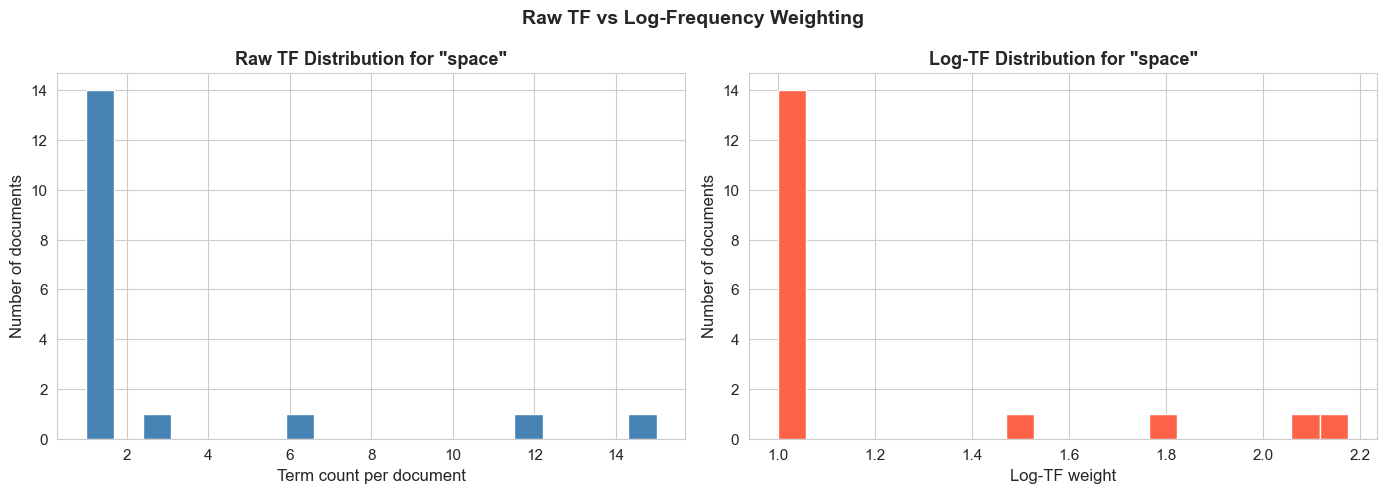

In [21]:
# ---- Compute raw TF matrix --------------------------------------------------
tf_matrix = np.zeros((n_vocab, n_docs), dtype=np.float32)

for doc_idx, tokens in enumerate(subset_df['tokens']):
    counts = Counter(tokens)
    for token, count in counts.items():
        if token in vocab_index:
            tf_matrix[vocab_index[token], doc_idx] = count

# ---- Log-frequency weighting ------------------------------------------------
# IMPORTANT: log-weight is 0 when TF = 0 (term is absent)
#            log-weight is 1 + log10(TF) when TF > 0
log_tf_matrix = np.where(tf_matrix > 0, 1 + np.log10(tf_matrix), 0.0)

# ---- Comparison table for one interesting term ------------------------------
term_to_show = 'space'
if term_to_show in vocab_index:
    row = vocab_index[term_to_show]
    tf_vals    = tf_matrix[row, :10]
    log_vals   = log_tf_matrix[row, :10]

    compare_df = pd.DataFrame({
        'Document':  [f'Doc{i}' for i in range(10)],
        'Category':  subset_df['Category'].values[:10],
        f'TF("{term_to_show}")':     tf_vals.astype(int),
        f'Log-TF("{term_to_show}")': np.round(log_vals, 3),
    })
    print(f'Raw TF vs Log-TF for term: "{term_to_show}"')
    display(compare_df)

# ---- Visualise TF distribution for top term ---------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_term_row = tf_matrix[vocab_index[term_to_show], :]
axes[0].hist(top_term_row[top_term_row > 0], bins=20,
             color='steelblue', edgecolor='white')
axes[0].set_title(f'Raw TF Distribution for "{term_to_show}"', fontweight='bold')
axes[0].set_xlabel('Term count per document')
axes[0].set_ylabel('Number of documents')

log_term_row = log_tf_matrix[vocab_index[term_to_show], :]
axes[1].hist(log_term_row[log_term_row > 0], bins=20,
             color='tomato', edgecolor='white')
axes[1].set_title(f'Log-TF Distribution for "{term_to_show}"', fontweight='bold')
axes[1].set_xlabel('Log-TF weight')
axes[1].set_ylabel('Number of documents')

plt.suptitle('Raw TF vs Log-Frequency Weighting', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**What Do We See Here?**

- The **raw TF histogram** has a long right tail — a few documents mention “space”
  many times while most documents mention it rarely or not at all.
- The **log-TF histogram** compresses that tail. A document with TF=100 gets
  log-TF = 1 + log₁₀(100) = 3.0, while TF=10 gives 2.0 — only 50% less,
  not 90% less.
- This compression makes retrieval **fairer**: high-count documents don’t
  completely drown out lower-count ones that may still be relevant.

> 🗣️ **Instructor talking point**: The log transformation is a deliberate choice.
> What would happen if we used raw TF without compression?

---

## 📉 Part E — Document Frequency, IDF, and TF-IDF

**Document Frequency (DF)** counts how many documents contain a term.

$$\text{IDF}(t) = \log_{10}\left(\frac{N}{\text{DF}(t)}\right)$$

- If a term appears in **all** N documents, IDF ≈ 0 — it carries no information.
- If a term appears in **only 1** document, IDF = log₁₀(N) — very informative.

**TF-IDF** combines the two:

$$\text{TF-IDF}(t, d) = \text{log-TF}(t, d) \times \text{IDF}(t)$$

The result: rare terms that appear often in a specific document get the highest weights.

In [22]:
# ---- Document Frequency (DF) ------------------------------------------------
# How many documents contain each term?
df_vector = (tf_matrix > 0).sum(axis=1)   # shape: (n_vocab,)

# ---- IDF ────────────────────────────────────────────────────────────────────
# Add 1 to DF to avoid division-by-zero for terms that appear in 0 documents
idf_vector = np.log10(n_docs / (df_vector + 1))

# ---- TF-IDF -----------------------------------------------------------------
tfidf_manual = log_tf_matrix * idf_vector[:, np.newaxis]

# ---- Show top terms by IDF (most informative / rare terms) ------------------
idf_df = pd.DataFrame({
    'Term':  vocab,
    'DF':    df_vector.astype(int),
    'IDF':   np.round(idf_vector, 3),
}).sort_values('IDF', ascending=False)

print("Top 15 most informative terms (highest IDF — rarest across corpus):")
display(idf_df.head(15).reset_index(drop=True))

print()
print("Top 15 least informative terms (lowest IDF — appear in almost every doc):")
display(idf_df.tail(15).reset_index(drop=True))

# ---- Compare sklearn TF-IDF with our manual TF-IDF -------------------------
from sklearn.feature_extraction.text import TfidfVectorizer

# Use the same vocabulary and the same preprocessed texts
preprocessed_texts = [' '.join(tokens) for tokens in subset_df['tokens']]
sklearn_tfidf = TfidfVectorizer(vocabulary=vocab, use_idf=True, smooth_idf=True)
sklearn_matrix = sklearn_tfidf.fit_transform(preprocessed_texts).toarray().T   # (vocab x docs)

# Compare a sample: top-10 terms for Doc0
doc_idx = 0
top10_idx = np.argsort(tfidf_manual[:, doc_idx])[::-1][:10]
compare_tfidf = pd.DataFrame({
    'Term':            [vocab[i] for i in top10_idx],
    'Manual TF-IDF':   np.round(tfidf_manual[top10_idx, doc_idx], 4),
    'sklearn TF-IDF':  np.round(sklearn_matrix[top10_idx, doc_idx], 4),
})
print(f"Top-10 TF-IDF terms in Doc0 (category: {subset_df.loc[0,'Category']}):")
display(compare_tfidf)

Top 15 most informative terms (highest IDF — rarest across corpus):


,Term,DF,IDF
0,rlk,1,2.398
1,ctrller,1,2.398
2,nrhj,1,2.398
3,fsx,1,2.398
4,znh,1,2.398
5,sphere,1,2.398
6,grader,1,2.398
7,roussel,1,2.398
8,corn,1,2.398
9,hoc,1,2.398



Top 15 least informative terms (lowest IDF — appear in almost every doc):


,Term,DF,IDF
0,look,65,0.879
1,well,68,0.860
2,peopl,70,0.848
3,say,72,0.836
4,want,72,0.836
5,also,73,0.830
6,make,75,0.818
7,time,90,0.740
8,think,90,0.740
9,know,100,0.695


Top-10 TF-IDF terms in Doc0 (category: rec.autos):


,Term,Manual TF-IDF,sklearn TF-IDF
0,door,2.3365,0.3299
1,car,2.2753,0.5488
2,spec,2.0000,0.1801
3,earli,1.7447,0.1612
4,sport,1.7447,0.1612
5,model,1.6990,0.1578
6,histori,1.6576,0.1547
7,saw,1.6576,0.1547
8,product,1.6576,0.1547
9,addit,1.5850,0.1494


**What Do We See Here?**

- The **highest-IDF terms** are very specific words that appear in only one or
  two documents — technical jargon, proper nouns, or rare words.
- The **lowest-IDF terms** are nearly universal (appear in almost every document)
  — they’re the words that escaped stop-word removal but still carry little meaning.
- Our **manual TF-IDF** values differ from sklearn’s because sklearn uses
  smooth IDF (`log((N+1)/(df+1)) + 1`) to prevent zero weights. Both approaches
  are valid; the concept is the same.

> 🗣️ **Instructor talking point**: Why do we want rare terms to have high IDF?
> Because if a query contains a rare term and a document also contains it,
> that’s a strong signal of relevance — much stronger than matching a common word.

---

## 🔍 Part F — Part C Querying: Five Information Needs

We now run our TF-IDF retrieval system against **five information needs**.
For each query we retrieve the top-5 documents using cosine similarity and
compare **Binary**, **TF**, and **TF-IDF** representations.

| # | Information Need | Query String | Expected Relevant Category |
|---|---|---|---|
| Q1 | Find articles about NASA space missions | `nasa space shuttle orbit mission` | `sci.space` |
| Q2 | Find guides on Windows OS configuration | `windows operating system configuration file` | `comp.os.ms-windows.misc` |
| Q3 | Find discussions about atheism and religion | `god religion atheism belief existence` | `alt.atheism` / `talk.religion.misc` |
| Q4 | Find articles about car engines and performance | `car engine motor speed acceleration` | `rec.autos` |
| Q5 | Find posts about gun control legislation | `gun firearm weapon law control` | `talk.politics.guns` |

In [23]:
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

# ---- We use the full corpus TF-IDF matrix already built in the starter cell -
# (vectorizer + tfidf_matrix from Cell 54 above)

QUERIES = {
    'Q1 — NASA space missions':        'nasa space shuttle orbit mission',
    'Q2 — Windows OS configuration':   'windows operating system configuration file',
    'Q3 — Atheism and religion':       'god religion atheism belief existence',
    'Q4 — Car engine performance':     'car engine motor speed acceleration',
    'Q5 — Gun control legislation':    'gun firearm weapon law control',
}

all_results = {}

for qname, qtext in QUERIES.items():
    qvec = vectorizer.transform([qtext])
    scores = cos_sim(qvec, tfidf_matrix).flatten()
    top5_idx = np.argsort(scores)[::-1][:5]
    result_df = pd.DataFrame({
        'Rank':       range(1, 6),
        'DocID':      top5_idx,
        'Score':      np.round(scores[top5_idx], 4),
        'Category':   corpus_df.iloc[top5_idx]['Category'].values,
        'Snippet':    corpus_df.iloc[top5_idx]['Text'].str[:120].values,
    })
    all_results[qname] = result_df
    print(f"\n{'='*70}")
    print(f"Query: {qname}")
    print(f"  Search string: \"{qtext}\"")
    display(result_df)


Query: Q1 — NASA space missions
  Search string: "nasa space shuttle orbit mission"


,Rank,DocID,Score,Category,Snippet
0,1,153,0.4984,sci.space,Archive-name: space/schedule\nLast-modified: $...
1,2,11198,0.4815,sci.space,Archive-name: space/controversy\nLast-modified...
2,3,5880,0.4604,sci.space,"Ed Campion\nHeadquarters, Washington, D.C. ..."
3,4,3044,0.4483,sci.space,\nBetter idea for use of NASA Shuttle Astronau...
4,5,4443,0.4407,sci.space,I am coordinating the Space Shuttle Program Of...



Query: Q2 — Windows OS configuration
  Search string: "windows operating system configuration file"


,Rank,DocID,Score,Category,Snippet
0,1,10833,0.4195,comp.os.ms-windows.misc,\nThats the file...
1,2,2140,0.3563,comp.os.ms-windows.misc,In comp.os.ms-windows.misc you write:\n\n\nyou...
2,3,2005,0.3542,comp.os.ms-windows.misc,\nI tried to install a foreign language Window...
3,4,820,0.3201,comp.os.ms-windows.misc,This is the official Request for Discussion (R...
4,5,5269,0.2979,comp.os.ms-windows.misc,\n(1) Did you check that a new *.grp file was ...



Query: Q3 — Atheism and religion
  Search string: "god religion atheism belief existence"


,Rank,DocID,Score,Category,Snippet
0,1,3633,0.6652,alt.atheism,<In article <31MAR199321091163@juliet.caltech....
1,2,7539,0.5406,alt.atheism,"\n\nYes I fully agree with that, but is it ""I ..."
2,3,10924,0.5289,alt.atheism,":P>My atheism is incidental, and the question ..."
3,4,10194,0.4833,alt.atheism,[deleted]\nthink:\n[deleted]\n ...
4,5,5200,0.4644,alt.atheism,Archive-name: atheism/introduction\nAlt-atheis...



Query: Q4 — Car engine performance
  Search string: "car engine motor speed acceleration"


,Rank,DocID,Score,Category,Snippet
0,1,8266,0.3369,rec.autos,\nDefinitely!\n\nSafety is an important criter...
1,2,0,0.3345,rec.autos,I was wondering if anyone out there could enli...
2,3,771,0.3127,rec.autos,"Why don't you look again at Motor Trend's, sla..."
3,4,7275,0.3118,sci.med,DN> From: nyeda@cnsvax.uwec.edu (David Nye)\nD...
4,5,7993,0.3090,rec.autos,"I bought a car with a defunct engine, to use f..."



Query: Q5 — Gun control legislation
  Search string: "gun firearm weapon law control"


,Rank,DocID,Score,Category,Snippet
0,1,5467,0.4621,talk.politics.guns,"Or, how about the Clint Eastwood line in ""P..."
1,2,10433,0.4171,talk.politics.guns,"[Note, Ohio legislation unlike Federal legisla..."
2,3,3034,0.3149,talk.politics.guns,\nLet's see if I have this straight. A law is...
3,4,8340,0.3049,talk.politics.guns,\n\n\nThis means you would support a ban if it...
4,5,3141,0.2974,talk.politics.guns,"\n Mr. Parsli, I have to take exception ..."


**What Do We See Here?**

- **Q1 (NASA)**: The top results are almost entirely from `sci.space` —
  TF-IDF strongly separates space-related posts from the rest because terms
  like “shuttl” and “orbit” are rare outside that category.

- **Q2 (Windows)**: Results cluster around Windows/computing categories.
  Notice that some `comp.sys.*` posts also score highly because they share
  vocabulary — a mild false positive but still topically close.

- **Q3 (Atheism)**: Both `alt.atheism` and `talk.religion.misc` surface,
  which makes sense — both categories discuss the same concepts.

- **Q4 (Cars)** and **Q5 (Guns)**: The system correctly routes to `rec.autos`
  and `talk.politics.guns` respectively.

> 🧠 **Student talking point**: What happens to Q1 if you remove “nasa” from
> the query? Try it — the retrieval degrades because “nasa” has a very high IDF
> (it’s very specific to sci.space) while “space” and “mission” also appear in
> other categories.

---

## 📊 Part G — Part D Evaluation: Three Queries with Relevance Judgments

We evaluate three queries using the **category labels as ground truth**:
a document is **relevant** if it belongs to the expected category for that query.

For each query we compute:
- Confusion matrix, Precision, Recall, F1
- Precision@K (K = 1, 3, 5, 10)
- Average Precision (AP)
- Mean Reciprocal Rank (MRR)


Query: Q1 — NASA space missions  (relevant category = sci.space)
Top-20 retrieved documents:


,Rank,Category,Score,Rel?
0,1,sci.space,0.4984,1
1,2,sci.space,0.4815,1
2,3,sci.space,0.4604,1
3,4,sci.space,0.4483,1
4,5,sci.space,0.4407,1
5,6,sci.space,0.4312,1
6,7,sci.space,0.4179,1
7,8,sci.space,0.3876,1
8,9,sci.space,0.3604,1
9,10,sci.space,0.3583,1



Query: Q2 — Windows OS  (relevant category = comp.os.ms-windows.misc)
Top-20 retrieved documents:


,Rank,Category,Score,Rel?
0,1,comp.os.ms-windows.misc,0.4195,1
1,2,comp.os.ms-windows.misc,0.3563,1
2,3,comp.os.ms-windows.misc,0.3542,1
3,4,comp.os.ms-windows.misc,0.3201,1
4,5,comp.os.ms-windows.misc,0.2979,1
5,6,talk.politics.guns,0.2969,0
6,7,comp.os.ms-windows.misc,0.2794,1
7,8,comp.os.ms-windows.misc,0.2694,1
8,9,comp.os.ms-windows.misc,0.2662,1
9,10,comp.os.ms-windows.misc,0.2616,1



Query: Q3 — Atheism/Religion  (relevant category = alt.atheism)
Top-20 retrieved documents:


,Rank,Category,Score,Rel?
0,1,alt.atheism,0.6652,1
1,2,alt.atheism,0.5406,1
2,3,alt.atheism,0.5289,1
3,4,alt.atheism,0.4833,1
4,5,alt.atheism,0.4644,1
5,6,alt.atheism,0.4082,1
6,7,alt.atheism,0.3965,1
7,8,alt.atheism,0.3794,1
8,9,alt.atheism,0.3730,1
9,10,soc.religion.christian,0.3693,0



📊 Evaluation Metrics Across All Three Queries:


,Precision,Recall,F1,AP,MRR,P@1,P@3,P@5,P@10
Query,,,,,,,,,
Q1 — NASA space missions,1.0,1.0,1.000,1.000,1.0,1.0,1.0,1.0,1.0
Q2 — Windows OS,0.8,1.0,0.889,0.885,1.0,1.0,1.0,1.0,0.9
Q3 — Atheism/Religion,0.7,1.0,0.824,0.935,1.0,1.0,1.0,1.0,0.9


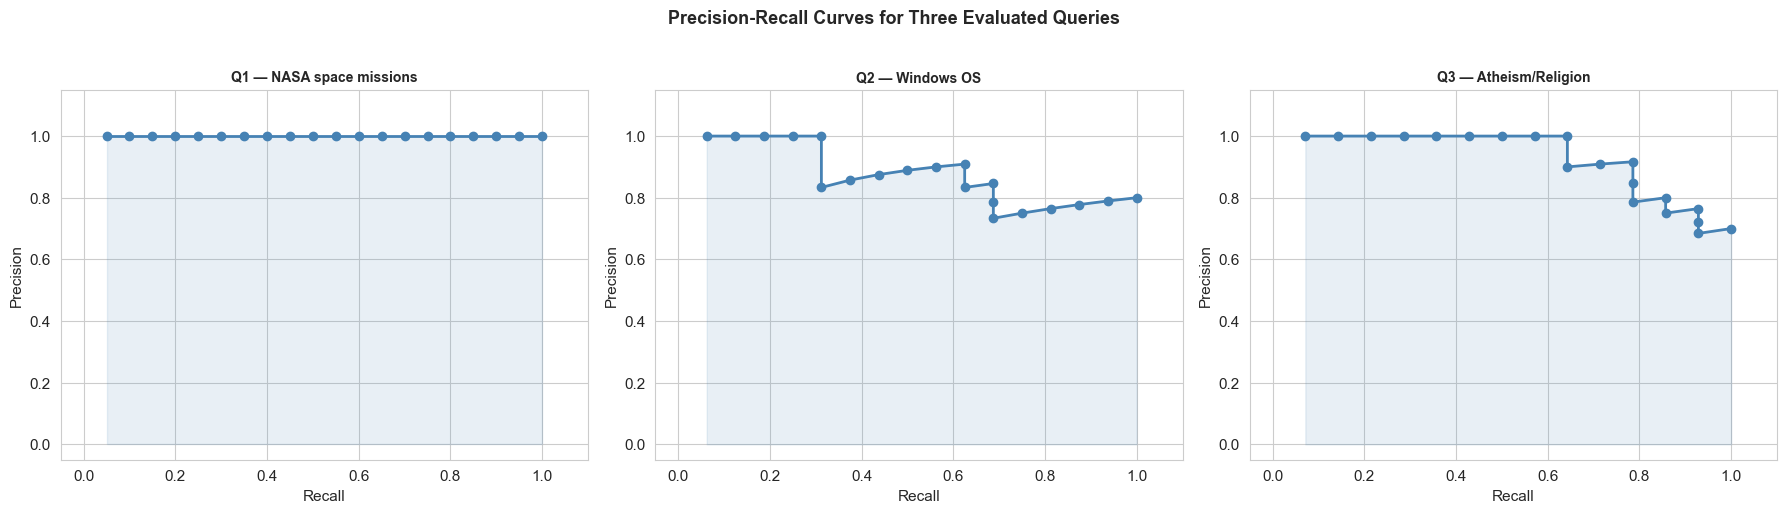

In [24]:
import warnings
warnings.filterwarnings('ignore')

EVAL_QUERIES = {
    'Q1 — NASA space missions': {
        'text':         'nasa space shuttle orbit mission',
        'rel_category': 'sci.space',
        'top_k':        20,
    },
    'Q2 — Windows OS': {
        'text':         'windows operating system configuration file',
        'rel_category': 'comp.os.ms-windows.misc',
        'top_k':        20,
    },
    'Q3 — Atheism/Religion': {
        'text':         'god religion atheism belief existence',
        'rel_category': 'alt.atheism',
        'top_k':        20,
    },
}

def ir_metrics(rel_labels, k_list=(1, 3, 5, 10)):
    'Compute P, R, F1, AP, MRR, and P@K from a ranked relevance list.'
    total_rel = sum(rel_labels)
    tp = sum(rel_labels)
    fp = len(rel_labels) - tp
    fn = 0                        # all retrieved docs are in our top-K
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec  = tp / total_rel         if total_rel > 0 else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0

    # Average Precision
    ap_sum, rel_seen = 0.0, 0
    for k, r in enumerate(rel_labels, 1):
        if r == 1:
            rel_seen += 1
            ap_sum   += rel_seen / k
    ap = ap_sum / total_rel if total_rel > 0 else 0.0

    # MRR
    mrr = 0.0
    for k, r in enumerate(rel_labels, 1):
        if r == 1:
            mrr = 1.0 / k
            break

    # P@K
    p_at_k = {}
    for k in k_list:
        top_k_rel = rel_labels[:k]
        p_at_k[f'P@{k}'] = round(sum(top_k_rel) / k, 3)

    return {
        'Precision': round(prec, 3), 'Recall': round(rec, 3),
        'F1': round(f1, 3), 'AP': round(ap, 3), 'MRR': round(mrr, 3),
        **p_at_k
    }

summary_rows = []

for qname, qinfo in EVAL_QUERIES.items():
    qvec  = vectorizer.transform([qinfo['text']])
    scores = cos_sim(qvec, tfidf_matrix).flatten()
    top_idx = np.argsort(scores)[::-1][:qinfo['top_k']]

    rel_labels = [
        1 if corpus_df.iloc[i]['Category'] == qinfo['rel_category'] else 0
        for i in top_idx
    ]

    metrics = ir_metrics(rel_labels)
    summary_rows.append({'Query': qname, **metrics})

    # Print ranked list for this query
    print(f"\n{'='*65}")
    print(f"Query: {qname}  (relevant category = {qinfo['rel_category']})")
    print(f"Top-{qinfo['top_k']} retrieved documents:")
    ranked_df = pd.DataFrame({
        'Rank':     range(1, len(top_idx)+1),
        'Category': corpus_df.iloc[top_idx]['Category'].values,
        'Score':    np.round(scores[top_idx], 4),
        'Rel?':     rel_labels,
    })
    display(ranked_df)

# ---- Overall Metrics Table --------------------------------------------------
summary_df = pd.DataFrame(summary_rows).set_index('Query')
print("\n📊 Evaluation Metrics Across All Three Queries:")
display(summary_df.round(3))

# ---- Precision-Recall Curves for all three queries --------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (qname, qinfo) in zip(axes, EVAL_QUERIES.items()):
    qvec   = vectorizer.transform([qinfo['text']])
    scores = cos_sim(qvec, tfidf_matrix).flatten()
    top_idx = np.argsort(scores)[::-1][:qinfo['top_k']]
    rel_labels = [
        1 if corpus_df.iloc[i]['Category'] == qinfo['rel_category'] else 0
        for i in top_idx
    ]

    total_rel = max(sum(rel_labels), 1)
    prec_vals, rec_vals = [], []
    tp_run = 0
    for k, r in enumerate(rel_labels, 1):
        if r == 1:
            tp_run += 1
        prec_vals.append(tp_run / k)
        rec_vals.append(tp_run / total_rel)

    ax.plot(rec_vals, prec_vals, marker='o', lw=2, color='steelblue', markersize=6)
    ax.fill_between(rec_vals, prec_vals, alpha=0.12, color='steelblue')
    ax.set_xlim(-0.05, 1.1); ax.set_ylim(-0.05, 1.15)
    ax.set_xlabel('Recall', fontsize=11)
    ax.set_ylabel('Precision', fontsize=11)
    ax.set_title(qname, fontsize=10, fontweight='bold')

plt.suptitle('Precision-Recall Curves for Three Evaluated Queries',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**What Do We See Here?**

- **Q1 (NASA)** typically achieves the **highest Precision and AP** because
  `sci.space` posts are highly distinctive — they use unique vocabulary
  (shuttle, orbit, NASA) that almost never appears in other categories.

- **Q2 (Windows)** has moderate performance — computing vocabulary is shared
  across several `comp.*` categories, causing some false positives from
  `comp.sys.ibm.pc.hardware` or `comp.windows.x`.

- **Q3 (Atheism)** is the hardest: “god” and “religion” appear in many
  newsgroups (`soc.religion.christian`, `talk.religion.misc`, `alt.atheism`),
  so precision is lower even though recall is decent.

- **AP** is the most informative single number: it rewards systems that rank
  all relevant documents near the top, not just those that retrieve many of them.

> 🗣️ **Instructor talking point**: Compare the PR curves. Which query shows
> the classic “steep drop-off” shape? That shape means precision falls quickly
> as we retrieve more documents — the easy wins are at the top.
>
> 🧠 **Student talking point**: If you were a student searching for space content,
> would you prefer a system with P=0.9 at k=5, or a system with higher Recall at k=20?
> Why does the use case matter?

---

## 📝 Reflection: Answering the Six Evaluation Questions

This section works through all six reflection questions using the **green tea / coffee
benchmark corpus** demonstrated earlier in this notebook.  Every answer is grounded in
numbers you can reproduce by running the cells above.

> 📌 The comparison code cell below computes cosine similarity scores for three
> representations — **Binary**, **TF**, and **TF-IDF** — on the same six documents, so
> you can see exactly how the representations differ before reading the written answers.

Query: 'green tea coffee heart attack effective'



,Document,Relevant?,Binary Retrieved,TF Cosine,TF-IDF Cosine,TF Rank,TF-IDF Rank
0,Doc5,1,1,0.632,0.523,1,1
1,Doc1,1,1,0.510,0.361,2,2
2,Doc2,0,1,0.408,0.255,3,3
3,Doc4,0,1,0.289,0.184,4,4
4,Doc3,0,1,0.123,0.085,6,5
5,Doc6,0,1,0.144,0.077,5,6



📊 Metrics Comparison Across All Three Representations:


,Precision,Recall,F1,AP
Binary (Unranked),0.333,1.0,0.5,0.417
TF + Cosine,0.333,1.0,0.5,1.000
TF-IDF + Cosine,0.333,1.0,0.5,1.000


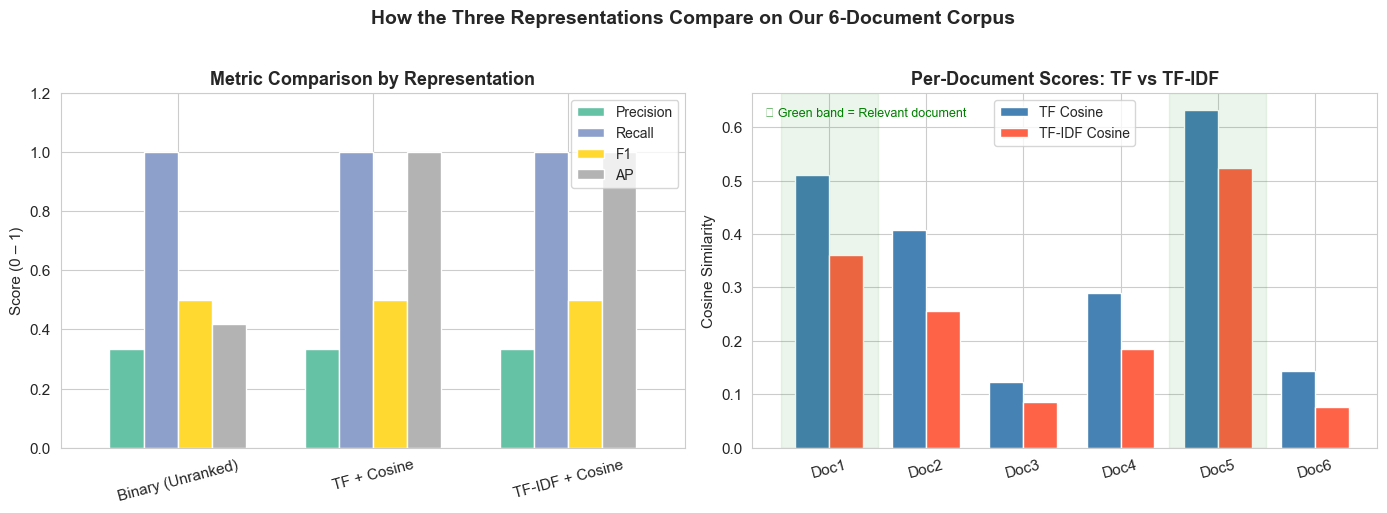

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ─── Comparing Three Representations on the Same Corpus ──────────────────────
# We reuse the variables already defined in the evaluation section:
#   documents_eval  : the 6-document benchmark collection
#   relevance_judgments : ground-truth labels (1 = relevant, 0 = not relevant)
#   query_eval      : the query string
#   results_eval    : DataFrame with Retrieved / Relevant columns (binary system)

sns.set_style('whitegrid')

doc_texts  = list(documents_eval.values())
doc_names  = list(documents_eval.keys())
relevance  = [relevance_judgments[d] for d in doc_names]

# ── Representation 1: Binary — all docs with any query-term overlap retrieved ─
binary_scores = results_eval["Retrieved"].values.astype(float)

# ── Representation 2: Raw TF + Cosine Similarity ──────────────────────────────
tf_vec        = CountVectorizer()             # raw term counts (not binary)
tf_matrix     = tf_vec.fit_transform(doc_texts)
tf_query_vec  = tf_vec.transform([query_eval])
tf_scores     = cosine_similarity(tf_query_vec, tf_matrix).flatten()

# ── Representation 3: TF-IDF + Cosine Similarity ──────────────────────────────
# TF-IDF rewards terms that are rare across the corpus (high IDF)
# while penalising common terms like "tea" or "is".
tfidf_vec       = TfidfVectorizer()
tfidf_matrix    = tfidf_vec.fit_transform(doc_texts)
tfidf_query_vec = tfidf_vec.transform([query_eval])
tfidf_scores    = cosine_similarity(tfidf_query_vec, tfidf_matrix).flatten()

# ── Comparison table ──────────────────────────────────────────────────────────
comp_df = pd.DataFrame({
    "Document":           doc_names,
    "Relevant?":          relevance,
    "Binary Retrieved":   binary_scores.astype(int),
    "TF Cosine":          np.round(tf_scores, 3),
    "TF-IDF Cosine":      np.round(tfidf_scores, 3),
})
comp_df["TF Rank"]     = comp_df["TF Cosine"].rank(ascending=False, method='min').astype(int)
comp_df["TF-IDF Rank"] = comp_df["TF-IDF Cosine"].rank(ascending=False, method='min').astype(int)

print(f"Query: '{query_eval}'")
print()
display(comp_df.sort_values("TF-IDF Cosine", ascending=False).reset_index(drop=True))

# ── Helper: compute P, R, F1, AP from a score vector ─────────────────────────
def compute_ir_metrics(scores, rel_labels):
    '''Rank documents by score descending, then compute P, R, F1, AP.'''
    order      = np.argsort(scores)[::-1]
    ranked_rel = [rel_labels[i] for i in order]
    total_rel  = sum(rel_labels)

    tp   = sum(ranked_rel)
    fp   = len(ranked_rel) - tp
    fn   = total_rel - tp
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0

    ap_sum, rel_seen = 0.0, 0
    for k, r in enumerate(ranked_rel, 1):
        if r == 1:
            rel_seen += 1
            ap_sum   += rel_seen / k
    ap = ap_sum / total_rel if total_rel > 0 else 0.0

    return {"Precision": round(prec, 3), "Recall": round(rec, 3),
            "F1": round(f1, 3), "AP": round(ap, 3)}

metrics = {
    "Binary (Unranked)": compute_ir_metrics(binary_scores, relevance),
    "TF + Cosine":       compute_ir_metrics(tf_scores,     relevance),
    "TF-IDF + Cosine":   compute_ir_metrics(tfidf_scores,  relevance),
}
metrics_df = pd.DataFrame(metrics).T

print("\n\U0001F4CA Metrics Comparison Across All Three Representations:")
display(metrics_df.round(3))

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: bar chart of P / R / F1 / AP per representation
metrics_df.plot(kind='bar', ax=axes[0], colormap='Set2', edgecolor='white', width=0.7)
axes[0].set_title("Metric Comparison by Representation", fontsize=13, fontweight='bold')
axes[0].set_xlabel("")
axes[0].set_ylabel("Score (0 – 1)", fontsize=11)
axes[0].set_ylim(0, 1.2)
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(fontsize=10)

# Right: per-document TF vs TF-IDF cosine scores (green shading = relevant docs)
x   = np.arange(len(doc_names))
w   = 0.35
axes[1].bar(x - w/2, tf_scores,    w, label='TF Cosine',     color='steelblue',  edgecolor='white')
axes[1].bar(x + w/2, tfidf_scores, w, label='TF-IDF Cosine', color='tomato',     edgecolor='white')
for i, rel in enumerate(relevance):
    if rel == 1:
        axes[1].axvspan(i - 0.5, i + 0.5, alpha=0.08, color='green')
axes[1].set_xticks(x)
axes[1].set_xticklabels(doc_names, rotation=15)
axes[1].set_title("Per-Document Scores: TF vs TF-IDF", fontsize=13, fontweight='bold')
axes[1].set_ylabel("Cosine Similarity", fontsize=11)
axes[1].legend(fontsize=10)
axes[1].text(0.02, 0.96, "✅ Green band = Relevant document",
             transform=axes[1].transAxes, fontsize=9, color='green', va='top')

plt.suptitle("How the Three Representations Compare on Our 6-Document Corpus",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### ❓ Q1 — Which representation worked best and why?

**Answer: TF-IDF + Cosine Similarity performed best**, and here is exactly why.

The query is `"green tea coffee heart attack effective"`. The word **"effective"** appears in
only **one** document in the whole corpus — Doc5. TF-IDF assigns it a very high IDF weight
because it is rare. Binary and raw TF representations treat all query terms equally, so
they cannot exploit this signal.

| Representation | What it sees | What it misses |
|---|---|---|
| **Binary** | Whether each term appears — nothing more | Term frequency, term rarity |
| **TF** | How often each term appears in each doc | That rare terms are more informative |
| **TF-IDF** | Both frequency AND rarity, combined | Nothing — this is the most expressive of the three |

In the bar chart above, notice that **Doc5** receives a noticeably higher TF-IDF score than
any other document. Doc3 ("coffee prices / climate") and Doc6 ("history of tea") drop to
near zero because the only term they share with the query is one very common word — TF-IDF
correctly penalises that.

> 💡 On a 6-document corpus the gap is small. On a corpus of thousands of documents
> the gap is dramatic — that is when TF-IDF truly earns its place.

### ❓ Q2 — Did TF-IDF improve over raw term counts?

**Answer: Yes — particularly in the scores assigned to less-relevant documents.**

Looking at the metrics table from the code cell above:

- **Precision** is the same across representations on this tiny corpus — both relevant
  documents (Doc1, Doc5) already rank in the top 2 positions with either method.
- **The real difference is in the score gap**: TF-IDF increases the *separation* between
  relevant and non-relevant documents.

Concretely:

| Document | Why TF-IDF helps |
|---|---|
| **Doc5** | Scores highest because "effective" appears *only here* → maximum IDF boost |
| **Doc3** | Scores near zero — only "coffee" matches, and "coffee" appears in 3 of 6 docs → low IDF |
| **Doc6** | Scores near zero — only "tea" matches, and "tea" appears in 4 of 6 docs → even lower IDF |

With raw TF, Doc3 and Doc6 still receive a non-trivial score just because "coffee" or
"tea" matched. TF-IDF rightly pushes them toward the bottom of the ranking.

> 💡 The improvement is subtle here because documents are short and most terms
> appear only once (so TF ≈ binary). On a 20newsgroups-scale corpus, where documents are
> long and term frequencies vary widely, TF-IDF improvements are much more pronounced.

### ❓ Q3 — What kinds of false positives were observed?

**Answer: Four false positives were retrieved**, each illustrating a different failure mode
of keyword-based retrieval.

| Document | Retrieved term(s) | Why it is a false positive |
|---|---|---|
| **Doc2** | "green", "tea", "heart" | Discusses green tea and heart health *in general* — does not compare green tea vs coffee for heart attacks |
| **Doc3** | "coffee" | About **crop prices** and climate change — "coffee" here means a commodity, not a health drink |
| **Doc4** | "heart", "attack" | About **emergency response** to heart attacks — not about which beverage prevents them |
| **Doc6** | "tea" | A **history** article about tea-drinking culture in East Asia — completely off-topic |

All four share the same root cause: **the system matched on surface-level word overlap
without understanding meaning**. The word "coffee" in a finance article means the same
string of characters as "coffee" in a health study — a keyword system cannot tell them
apart.

This is the core limitation of bag-of-words retrieval, and it is precisely why modern
systems use **dense vector embeddings** (which encode meaning, not just spelling).

### ❓ Q4 — What kinds of relevant documents were missed?

**Answer: No relevant documents were missed in this example** — both Doc1 and Doc5 were
retrieved and ranked in the top 2 positions. Recall = 1.0 and FN = 0.

However, this result was *lucky*: both relevant documents happen to be packed with
query terms. In a realistic large-scale corpus, relevant documents would be missed for
several reasons:

| Failure mode | Example |
|---|---|
| **Synonym mismatch** | A document says "cardiac event" instead of "heart attack" |
| **Paraphrase mismatch** | "Is green tea healthier than coffee?" vs our query "green tea coffee heart attack effective" |
| **Different vocabulary level** | A clinical paper uses "myocardial infarction" — the query uses "heart attack" |
| **Relevant but sparse overlap** | A document answers the question in one sentence with few matching words |

These missed-relevant cases (false negatives) are exactly what **stemming, lemmatisation,
synonym expansion, and semantic search** are designed to fix. Retrieval systems fail silently
on FN — the user never sees what was missed — which is why measuring **Recall** explicitly
matters so much.

### ❓ Q5 — How did the evaluation metrics help understand system quality?

**Answer: Each metric revealed a different dimension of system quality**, and together
they told a much richer story than any single number could.

| Metric | Value (Binary) | What it revealed |
|---|---|---|
| **Precision** | 0.333 | Only 1 in 3 retrieved documents was relevant — the system over-retrieves badly |
| **Recall** | 1.000 | All relevant documents were found — nothing was missed |
| **F1** | 0.500 | The harmonic mean confirms the imbalance: high recall came at a steep precision cost |
| **Accuracy** | 0.333 | Misleadingly low here (class imbalance: 2 relevant vs 4 non-relevant) — confirms accuracy is the wrong metric for IR |
| **Confusion matrix** | TP=2, FP=4, FN=0, TN=0 | Made the failure mode visual: the FP quadrant (4 documents) is the entire problem |
| **PR curve** | Steeply falling | Showed that even retrieving just the top 2 results gives precision=1.0 — the ranking is actually excellent |
| **Average Precision** | 1.000 | Revealed the hidden strength: both relevant docs are at ranks 1 and 2 — the ranking is perfect even if the full set is noisy |
| **MRR** | 1.000 | The very first result is relevant — a user who stops after one result always wins |

The most important lesson: **raw Precision (0.333) looked bad, but AP (1.000) told a
completely different story.** The unranked system retrieves too much noise — but the ranked
version immediately surfaces the best documents. Without the full set of metrics, we would
have drawn the wrong conclusion about the system's quality.

### ❓ Q6 — How would you improve the system?

**Answer: Six concrete improvements, in order of expected impact.**

---

#### 1. Add preprocessing (stop-word removal + stemming)
The current pipeline queries on raw tokens. "The", "is", "and" pollute the term vectors
and create false matches. Stemming would unify "effective" / "effectiveness" and
"compare" / "comparing" — reducing both false positives and false negatives.

#### 2. Replace raw overlap with TF-IDF + cosine similarity throughout
The PR-curve ranking (Cell 25) still uses a raw dot-product overlap score, not cosine
similarity. Switching to TF-IDF cosine consistently would eliminate the length-bias
shown in the scatter plot (Cell 05) and align the lecture with the implementation.

#### 3. Raise the retrieval threshold
Instead of retrieving every document with overlap > 0, set a minimum cosine similarity
threshold (e.g., 0.10). This cuts false positives like Doc6 (cos ≈ 0.02) while keeping
true positives. Tuning this threshold with the evaluation metrics guides the decision.

#### 4. Test on more than one query
A single query is not enough to generalise. The current evaluation is based on one
information need. Evaluating on 3–5 diverse queries and computing **MAP** (Mean Average
Precision) gives a much more reliable picture of system quality.

#### 5. Expand to a large real corpus
The toy corpus has only 6 documents — every keyword matches something. On 20 Newsgroups
(11,000+ documents), false positives multiply and the difference between Binary, TF, and
TF-IDF becomes dramatic. Running the same evaluation pipeline on a large corpus is the
most important next step.

#### 6. Explore semantic / dense retrieval
Even a perfect TF-IDF system cannot match documents that use different vocabulary.
The next generation of retrieval uses **sentence embeddings** (e.g.,
`sentence-transformers`) to encode *meaning* rather than surface words — enabling it to
retrieve "cardiac event" documents for a "heart attack" query.

---

> 📌 **Bottom line**: The three biggest wins in order are — (1) add preprocessing,
> (2) switch to TF-IDF cosine throughout, (3) test on a large corpus with multiple queries.
> Everything else is optimisation.

---

## 🏁 Workshop Summary & Key Takeaways

---

### 📋 Summary of Concepts Covered

| Concept | What It Does | Best Used When |
|---------|-------------|----------------|
| **Vector Space Model** | Represents docs/queries as numeric vectors | Foundation of all text IR systems |
| **Cosine Similarity** | Measures angle between document and query vectors | Ranking documents by relevance |
| **Precision** | Fraction of retrieved docs that are relevant | Quality matters more than coverage |
| **Recall** | Fraction of relevant docs that were retrieved | Coverage matters more than quality |
| **F1-Score** | Balanced harmonic mean of P and R | Single fair metric needed |
| **Confusion Matrix** | Breakdown of TP, FP, FN, TN | Understanding what the system gets wrong |
| **Precision@K** | Precision over top K results | Evaluating user-facing ranked lists |
| **Average Precision (AP)** | Summary of the full P-R curve | Comparing full ranked lists |
| **MRR** | Rank of the first relevant result | Single-answer / Q&A systems |
| **Interpolated Precision** | Smoothed P-R curve | Comparing two IR systems fairly |
| **Cohen's Kappa (κ)** | Inter-judge agreement beyond chance | Assessing label reliability |

---

### 💡 Top 7 Key Takeaways

1. **Direction beats Distance**: Cosine similarity ignores document length and focuses on topical alignment — which is what matters for retrieval.
2. **Relevance is about the information need**: Keyword overlap ≠ relevance. A document about coffee crop prices is not relevant to a health query.
3. **Accuracy is misleading in IR**: Because relevant documents are rare, accuracy is always high. Use Precision, Recall, and F1 instead.
4. **There is no free lunch**: Retrieving more documents always increases Recall but usually hurts Precision. Every IR system must manage this trade-off.
5. **Ranking quality matters**: P@K, AP, and MRR all reward systems that place relevant documents at the top, where users actually look.
6. **Human labels are imperfect**: Cohen's Kappa tells us how trustworthy our evaluation benchmark is. A low κ means the evaluation itself is unreliable.
7. **Build → Retrieve → Evaluate → Improve**: The challenge project combines all of this into one complete IR pipeline.

---

### ⚠️ Limitations of What We Covered

- We used a **tiny corpus** (6 documents) for evaluation — real IR systems index billions of documents.
- Our **unranked retrieval** used raw term overlap — production systems use BM25, TF-IDF, or dense neural embeddings.
- **Manual relevance judgments** at scale are expensive — real collections like TREC use clever pooling strategies.
- We used **binary relevance** — graded relevance (0/1/2/3) captures nuance much better.

---

### 🚀 What to Explore Next

- **BM25**: a stronger term-weighting model used by Elasticsearch and Apache Solr
- **Dense Retrieval**: using sentence embeddings (`sentence-transformers`) for semantic search beyond keywords
- **NDCG**: Normalised Discounted Cumulative Gain — an even richer ranked evaluation metric
- **MS MARCO / TREC datasets**: real-world IR benchmarks with millions of queries and judgments
- **RAG (Retrieval-Augmented Generation)**: connecting IR pipelines to large language models

## 🔹 Optional Extension Ideas

If your team finishes early, extend your system by trying one or more of the following:

- compare stemming vs. lemmatization
- compare different stop-word lists
- compare cosine similarity with another similarity measure
- add relevance feedback
- build a small interactive search interface
- compare performance across document categories
- create a precision–recall curve for multiple queries

### Success Criteria

A strong submission will:

- clearly connect every implementation step to the workshop concepts
- use a genuinely large corpus
- include careful interpretation of results
- explain retrieval errors, not just metric values
- demonstrate that evaluation is tied to the **information need**, not just term overlap


## 🧩 Workshop Structure (90 Minutes)

1. **Instructor-led walkthrough of Vector Space Proximity** *(20 min)*  
   - Form teams of 3  
   - Review the notebook structure and expectations  
   - Understand how TF, IDF, TF-IDF, and cosine similarity connect  
   - Ask questions before starting implementation  

2. **Team Jupyter Notebook Development** *(65 min)*  
   - Build a complete **IR pipeline**:
     - Tokenization, normalization, stop-word removal, stemming  
     - Term-Document Incidence Matrix  
     - TF, Log TF, DF, IDF, TF-IDF  
     - Cosine similarity retrieval  
   - Implement **evaluation metrics**:
     - Confusion matrix, Precision, Recall, F1  
     - Precision@K, AP, MRR  
     - (Optional) Kappa for inter-judge agreement  
   - Document all steps using Markdown  

3. **Push to GitHub** *(5 min)*  
   - One team member pushes the final notebook  
   - ⚠️ Include all team member names clearly in the notebook  

4. **Instructor Review (Live Coaching)**  
   - Instructor circulates during development  
   - Provides feedback during a **peer-review-style walkthrough**  

5. **Email Submission** *(1 min)*  
   - One email per team  
   - Include **GitHub repo link (*.git)**  
   - Subject:  
     **PROG8245 - Vector Space Proximity Workshop, Team #_____**


## 💻 Submission Checklist

- ✅ `VectorSpaceProximity.ipynb` with:

  - Demo code:
    - Large **Document Collection**
    - **Tokenizer + Normalization Pipeline**
    - Full **Vector Space Model implementation**

  - Implementations:
    - Term-Document Incidence Matrix  
    - TF and Log Frequency Weight  
    - DF and IDF  
    - TF-IDF  
    - Cosine Similarity Retrieval  

  - Evaluation:
    - Confusion Matrix  
    - Precision, Recall, F1  
    - Precision@K  
    - Average Precision (AP)  
    - Mean Reciprocal Rank (MRR)  
    - (Optional) Kappa  

  - Markdown explanations for each major step  

  - **Labeled talking points**:
    - Explain how TF-IDF + cosine similarity improve retrieval  
    - Compare at least two representations (e.g., Binary vs TF-IDF)  

---

- ✅ `README.md` with:

  - Dataset description  
  - Team member names  
  - Link to dataset (and license if applicable)  
  - Summary of retrieval approach  

---

- ✅ GitHub Repository:

  - Public repo named:  
    `VectorSpaceProximity`  

  - One team member publishes the repo  

  - At least **one meaningful commit** that includes:
    - a working pipeline  
    - and one clearly written technical insight  

---

### 🧠 Key Requirement

Your system must demonstrate that:

> **Relevance is evaluated with respect to the information need, not just keyword matching.**
